conda create -n ai-econ-legacy python=3.7.16 -y
conda activate ai-econ-legacy

pip install "numpy==1.16.4"
pip install "tensorflow==1.14.0"
pip install "gym<0.23"
pip install "ray[rllib]==1.13.0"
pip install jupyter ipykernel tensorboard
python -m ipykernel install --user --name ai-econ-legacy --display-name "Python (ai-econ-legacy)"

In [2]:
import sys
import ray
import numpy as np
import tensorflow as tf
import gym


import os
import json
import pickle
import time
from copy import deepcopy

import numpy as np
import pandas as pd

import random

c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\s

In [3]:
sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

from utils import plotting

import ray
from ray.rllib.agents.ppo import PPOTrainer

C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-


In [4]:
from rllib.env_wrapper import RLlibEnvWrapper


# training sim

In [ ]:
# import os
# import warnings

# # TensorFlow / C++ logs
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# # Python warnings
# warnings.filterwarnings("ignore")

# # Ray logging
# os.environ["RAY_DISABLE_IMPORT_WARNING"] = "1"
# os.environ["RAY_DISABLE_MEMORY_MONITOR"] = "1"

# import simulation as exp

# import ray
# ray.shutdown()
# ray.init(ignore_reinit_error=True, log_to_driver=False, logging_level="ERROR")

# settings = exp.ExperimentSettings(
#     phase1_iters = 1,
#     phase2_iters = 1,
#     phase3a_iters = 1,
#     phase3b_iters = 1,
#     save_results=False,
#     travel_enabled_phase3a=False,
#     travel_enabled_phase3b=False,
#     restrict_trade_to_region = True,
#     experiment_extra_tag = "Original_with_travel",

    # fixed_tax_planner_id="p_top",
    # fixed_tax_bracket_rates=(0.30, 0.25, 0.20, 0.15, 0.10, 0.05, 0.00),
    # experiment_extra_tag="fixed_top_tax",

#     num_workers=0,
#     num_envs_per_worker=1,
#     num_gpus=1,
#     rollout_fragment_length=100,
#     train_batch_size=500,
#     sgd_minibatch_size=100,
#     num_sgd_iter=2,

#     # train_batch_size=6000,      # 15 workers * 2 envs * 200 steps
#     # sgd_minibatch_size=1500,
#     # num_sgd_iter=4,



# )

# results = exp.run_experiment(settings)

In [6]:
# from training_sim import results

# training_sim = results()

# training_sim["summary"]
# training_sim["metrics_df"]
# dense_logs = training_sim["dense_logs"]

In [7]:
# import simulation as exp

# phase_envs = exp.build_all_phase_env_configs(training_sim.settings)

# env_config_dict_phase3b = phase_envs["phase3b"]

# env_obj_phase1 = training_sim["envs"]["phase1"]
# env_obj_phase3b = training_sim["envs"]["phase3b"]

# trainer_phase3b = training_sim["trainers"]["phase3b"]

In [8]:
# state0 = dense_logs[0]["states"][0]
# for aid in sorted(int(k) for k in state0 if str(k).isdigit()):
#     s = state0[str(aid)]
#     row = int(s["loc"][0])
#     region_from_loc = "top" if row < 25 else "bottom"
#     print(aid, s["loc"], region_from_loc)

In [9]:
# last_state = dense_logs[0]["states"][-1]
# for aid in sorted(int(k) for k in last_state if str(k).isdigit()):
#     s = last_state[str(aid)]
#     row = int(s["loc"][0])
#     region_from_loc = "top" if row < 25 else "bottom"
#     print(aid, s["loc"], "cached:", s.get("region"), "from_loc:", region_from_loc)

In [10]:
# states = dense_logs[0]["states"]

# for aid in range(8):
#     rows = [int(s[str(aid)]["loc"][0]) for s in states]
#     started_top = rows[0] < 25
#     ever_crossed = any((r >= 25) for r in rows) if started_top else any((r < 25) for r in rows)
#     print(aid, "started_top" if started_top else "started_bottom", "ever_crossed =", ever_crossed)

In [11]:
# for t, state in enumerate(dense_logs[0]["states"]):
#     vals = []
#     for i in range(8):
#         s = state[str(i)]
#         vals.append((i, s.get("loc", None), s.get("location_region", None)))
#     print(t, vals)

In [12]:
# from tutorials import simulation as sim

# print("In-memory summary:", sim.summarize_dense_log(dense_logs[0]))

# last_state = dense_logs[0]["states"][-1]
# counts = {"top": 0, "bottom": 0}
# for i in range(8):
#     region = last_state[str(i)]["location_region"]
#     counts[region] += 1
#     print(i, last_state[str(i)]["loc"], region)

# print("Direct final counts:", counts)

In [13]:
# last_state = dense_logs[0]["states"][-1]

# counts = {"top": 0, "bottom": 0}
# for i in range(8):
#     state = last_state[str(i)]
#     region = state.get("location_region")
#     loc = state.get("loc")
#     print(i, loc, region)
#     if region in counts:
#         counts[region] += 1

# print("final counts:", counts)

In [14]:
# last_state = dense_logs[0]["states"][-1]
# for i in range(8):
#     s = last_state[str(i)]
#     print(i, "loc:", s.get("loc"), "region:", s.get("location_region"))

In [15]:
# def summarize_travel_events(dense_log):
#     if "CrossWaterTravel" not in dense_log:
#         print("No CrossWaterTravel log found.")
#         return

#     events = dense_log["CrossWaterTravel"]

#     counts = {}
#     for e in events:
#         aid = e["agent"]
#         counts[aid] = counts.get(aid, 0) + 1

#     print("Successful travels per agent:")
#     for aid in sorted(counts):
#         print(f"Agent {aid}: {counts[aid]}")

#     print("Total successful travels:", sum(counts.values()))

# summarize_travel_events(dense_logs[0])

# def print_travel_events(dense_log, max_events=30):
#     if "CrossWaterTravel" not in dense_log:
#         print("No CrossWaterTravel log found.")
#         return

#     events = dense_log["CrossWaterTravel"]
#     print(f"Showing first {min(len(events), max_events)} travel events:")
#     for e in events[:max_events]:
#         print(e)

# print_travel_events(dense_logs[0], max_events=50)

# def check_travel_cooldowns(dense_log, agent_id=0):
#     if "CrossWaterTravel" not in dense_log:
#         print("No CrossWaterTravel log found.")
#         return

#     ts = [e["t"] for e in dense_log["CrossWaterTravel"] if e["agent"] == agent_id]
#     print("Travel times:", ts)

#     if len(ts) > 1:
#         gaps = [ts[i+1] - ts[i] for i in range(len(ts)-1)]
#         print("Gaps:", gaps)

# check_travel_cooldowns(dense_logs[0], agent_id=0)

In [16]:
# def build_counts_by_agent(dense_log):
#     counts = {}
#     for b in dense_log.get("Build", []):
#         events = b.get("builds", []) if isinstance(b, dict) else b
#         for ev in events:
#             builder = str(ev.get("builder"))
#             counts[builder] = counts.get(builder, 0) + 1
#     print("build counts by agent:", counts)
#     print("total builds:", sum(counts.values()))
#     return counts

In [17]:
# build_counts_by_agent(dense_logs[0])

In [18]:
# obs = env_obj_phase3b.reset()

In [19]:
# (fig0, fig1, fig1_planner, fig2), incomes, endows, c_trades, all_builds = plotting.breakdown_all_agents(
#     dense_logs[0],
#     n_cols=4,
# )

In [20]:
# df_stone_t, df_stone_p, fig = plotting.diagnose_resource_market(dense_logs[0], resource="Stone", period=100)
# df_stone_p

In [21]:
# df_wood_t, df_wood_p, fig = plotting.diagnose_resource_market(dense_logs[1], resource="Wood", period=100)
# df_wood_p

In [22]:
# df_income, df_tax_counts = plotting.tax_day_income_report(dense_logs[0], period=100)
# df_income.head(20)
# df_tax_counts

In [23]:
# import matplotlib.pyplot as plt

# def plot_tax_group_counts(df_counts, region=None):
#     df = df_counts.copy()
#     if region is not None:
#         df = df[df["region"] == region]

#     pivot = df.pivot_table(
#         index="tax_day_number",
#         columns="tax_bracket",
#         values="n_agents",
#         aggfunc="sum",
#         fill_value=0,
#     )

#     fig, ax = plt.subplots(figsize=(10, 5))
#     pivot.plot(kind="bar", stacked=True, ax=ax)

#     title = "Agents in tax brackets by tax day"
#     if region is not None:
#         title += f" ({region})"
#     ax.set_title(title)
#     ax.set_xlabel("Tax day")
#     ax.set_ylabel("Number of agents")
#     ax.grid(True, axis="y")
#     ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
#     fig.tight_layout()
#     return fig, pivot

# fig, pivot = plot_tax_group_counts(df_tax_counts, region="top")
# fig, pivot = plot_tax_group_counts(df_tax_counts, region="top")

In [24]:
# df_inv = plotting.inventory_table_by_tax_period(dense_logs[0], period=100, include_escrow=True)
# df_inv

In [25]:
# coin_pivot = df_inv.pivot(index="tax_day_number", columns="agent", values="coin_total")
# coin_pivot

In [26]:
# df_inv.sort_values(["tax_day_number", "agent"]).reset_index(drop=True)

In [28]:
from pathlib import Path
import pickle

folder = "travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028"
result_run_dir = Path("results") / folder
if not result_run_dir.exists():
    result_run_dir = Path("tutorials/results") / folder

with open(result_run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs_from_results = pickle.load(f)

dense_log0 = dense_logs_from_results[0]
dense_log1 = dense_logs_from_results[1]


,tax_period,stone_trades,stone_inventory_total,stone_escrow_total,stone_on_map,builds
0,0,36,13.08,8.33,28.0,59.0
1,1,56,11.50,1.19,16.5,54.0
2,2,36,10.85,3.54,15.0,41.0
3,3,29,5.54,0.60,13.5,30.0
4,4,31,10.93,2.39,16.0,36.0
5,5,19,21.77,5.13,10.0,28.0
6,6,41,25.35,4.54,11.5,37.0
7,7,24,19.24,3.63,20.5,19.0
8,8,34,17.55,4.34,21.5,25.0
9,9,54,30.74,3.09,16.5,36.0


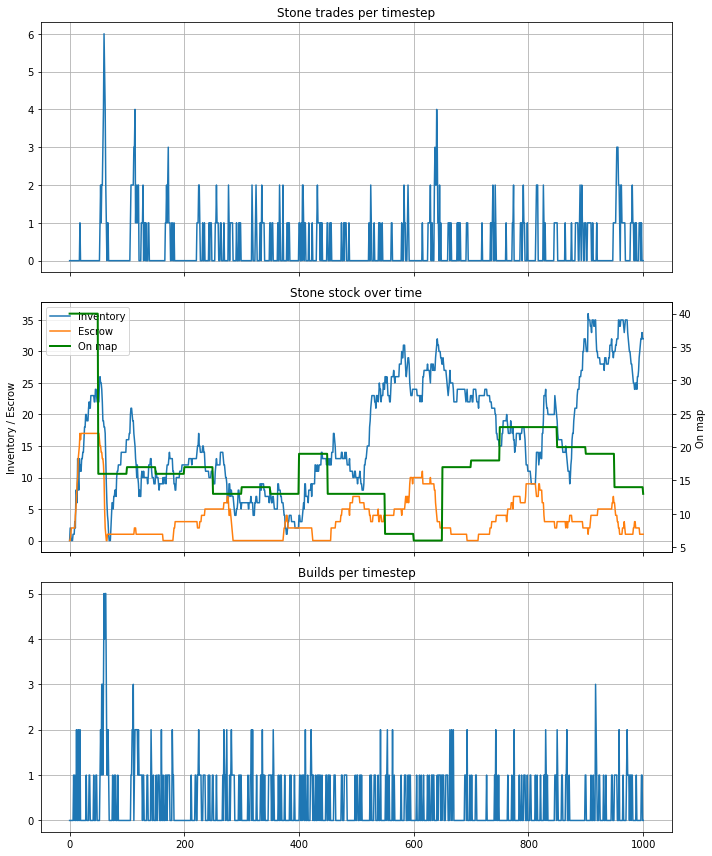

In [29]:
df_stone_t, df_stone_p, fig = plotting.diagnose_resource_market(dense_log0, resource="Stone", period=100)
df_stone_p

,tax_period,wood_trades,wood_inventory_total,wood_escrow_total,wood_on_map,builds
0,0,22,25.50,9.57,22.0,59.0
1,1,45,9.70,3.05,11.0,54.0
2,2,45,24.44,6.53,7.0,41.0
3,3,57,19.12,5.73,8.5,30.0
4,4,31,19.45,7.93,12.5,36.0
5,5,35,20.12,5.50,13.5,28.0
6,6,37,10.92,7.05,15.5,37.0
7,7,49,12.96,3.91,22.0,19.0
8,8,32,10.91,8.18,20.5,25.0
9,9,42,11.92,3.83,18.0,36.0


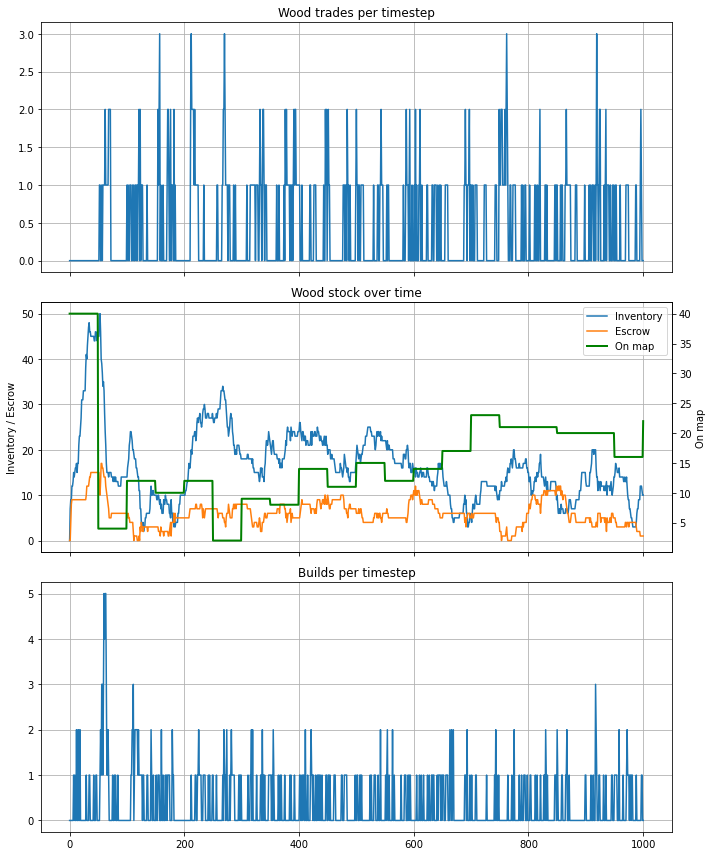

In [30]:
df_wood_t, df_wood_p, fig = plotting.diagnose_resource_market(dense_log0, resource="Wood", period=100)
df_wood_p

In [31]:
df_inv = plotting.inventory_table_by_tax_period(dense_log0, period=100, include_escrow=True)
df_inv

,tax_day_number,timestep,agent,region,coin_inventory,wood_inventory,stone_inventory,coin_escrow,wood_escrow,stone_escrow,coin_total,wood_total,stone_total
0,1,99,0,None,146.000000,0.0,8.0,31.0,1.0,0.0,177.000000,1.0,8.0
1,1,99,1,None,28.000000,0.0,4.0,30.0,1.0,0.0,58.000000,1.0,4.0
2,1,99,2,None,111.000000,2.0,0.0,22.0,2.0,0.0,133.000000,4.0,0.0
3,1,99,3,None,0.000000,0.0,0.0,7.0,0.0,1.0,7.000000,0.0,1.0
4,1,99,4,None,166.000000,5.0,0.0,18.0,0.0,0.0,184.000000,5.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,10,999,3,None,674.080312,0.0,16.0,30.0,0.0,0.0,704.080312,0.0,16.0
76,10,999,4,None,816.174063,8.0,3.0,15.0,1.0,0.0,831.174063,9.0,3.0
77,10,999,5,None,634.996562,1.0,0.0,18.0,0.0,0.0,652.996562,1.0,0.0
78,10,999,6,None,888.515312,0.0,1.0,15.0,0.0,0.0,903.515312,0.0,1.0


In [32]:
coin_pivot = df_inv.pivot(index="tax_day_number", columns="agent", values="coin_total")
coin_pivot

agent,0,1,2,3,4,5,6,7
tax_day_number,,,,,,,,
1,177.000000,58.000000,133.000000,7.000000,184.000000,68.000000,96.000000,44.000000
2,277.053437,169.357188,204.957187,211.632187,228.971875,143.519375,222.589375,175.919375
3,344.470937,252.604688,257.374687,454.549688,282.244375,197.651875,286.411875,300.691875
4,431.775625,291.989375,307.209375,403.025625,447.566875,288.274375,380.664375,347.494375
5,519.798437,363.248438,357.068438,518.884688,463.626875,344.964375,461.724375,520.684375
6,619.693437,423.503438,396.823438,525.979687,581.883437,424.368438,517.580938,463.167187
7,628.243437,475.653437,478.973437,578.129688,619.446250,490.011250,681.123750,631.418750
8,667.555937,516.965937,487.785937,569.692188,714.822813,595.187813,671.284063,657.705312
9,733.495312,563.905313,498.346563,570.252813,772.785313,617.600312,776.946562,689.667812


# comparison plots

In [33]:
def load_experiment_run(run_dir):
    import os, json, pickle

    with open(os.path.join(run_dir, "summary.json"), "r") as f:
        summary = json.load(f)

    dense_logs = None
    dense_log = None

    pkl_path = os.path.join(run_dir, "dense_logs_final.pkl")
    if os.path.exists(pkl_path):
        with open(pkl_path, "rb") as f:
            dense_logs = pickle.load(f)

        # keep old behavior too
        dense_log = dense_logs[0] if isinstance(dense_logs, dict) and 0 in dense_logs else None

    return {
        "run_dir": run_dir,
        "summary": summary,
        "dense_log": dense_log,
        "dense_logs": dense_logs,
    }

In [34]:
import os

BASE_RESULTS_DIR = "results"

selected_folders = [
    "travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028", #base

    "travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade_20260501_163728",

    "travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__with_travel_20260502_225247",
]

run_dirs = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders
]

# all_folders = sorted(os.listdir(BASE_RESULTS_DIR))
# for i, folder in enumerate(all_folders):
#     print(f"{i}: {folder}")

# selected_idx = [0, 1, 2]

# run_dirs_idx = [
#     os.path.join(BASE_RESULTS_DIR, all_folders[i])
#     for i in selected_idx
# ]

# print(run_dirs)

In [35]:
import pickle
from pathlib import Path

run_dir = Path(run_dirs[0])

with open(run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

print(dense_logs.keys())
print(len(dense_logs))

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
20


In [36]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
if str(PROJECT_ROOT / "tutorials") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "tutorials"))

import simulation as exp

run_dir = Path(run_dirs[0])

with open(run_dir / "config.json", "r") as f:
    cfg = json.load(f)

env_obj_phase3b = exp.create_env(cfg["env_config_dict_phase3b"])


In [37]:
# def load_experiment_run(run_dir):
#     with open(os.path.join(run_dir, "summary.json"), "r") as f:
#         summary = json.load(f)

#     metrics = pd.read_csv(os.path.join(run_dir, "training_metrics.csv"))

#     with open(os.path.join(run_dir, "dense_logs_final.pkl"), "rb") as f:
#         dense_logs = pickle.load(f)

#     # choose one representative dense log for single-rollout plots
#     if isinstance(dense_logs, dict) and 0 in dense_logs:
#         dense_log = dense_logs[0]
#     else:
#         dense_log = dense_logs

#     return {
#         "run_dir": run_dir,
#         "name": summary.get("experiment_name", os.path.basename(run_dir)),
#         "summary": summary,
#         "metrics": metrics,
#         "dense_logs": dense_logs,   # all dense logs
#         "dense_log": dense_log,     # one example dense log
#     }
# def load_experiment_runs(run_dirs):
#     return [load_experiment_run(rd) for rd in run_dirs]

In [38]:
runs = plotting.load_experiment_runs(run_dirs)

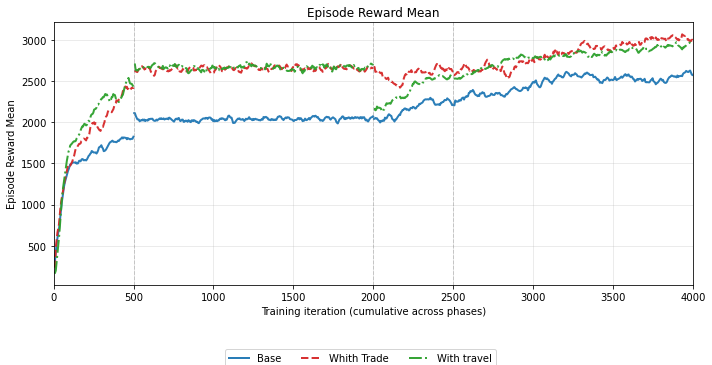

In [44]:
fig = plotting.compare_training_curves(
    runs,
    metric="episode_reward_mean",
    short_labels=["Base", "Whith Trade", "With travel"],
    smooth_window=5,
)

In [40]:
# fig = plotting.compare_training_curves(
#     runs,
#     metric="social_welfare_coin_eq_times_prod",
#     short_labels=["No travel", "With travel"],
#     smooth_window=5,
# )

In [41]:
def plot_planner_rewards(run, smooth_window=25):
    import pandas as pd
    import matplotlib.pyplot as plt

    df = run["metrics"].copy()
    df = df.reset_index(drop=True)
    x = range(len(df))

    fig, ax = plt.subplots(figsize=(10, 5))

    for col in ["policy_reward_mean/p_top", "policy_reward_mean/p_bottom"]:
        y = df[col].astype(float)
        if smooth_window > 1:
            y = y.rolling(smooth_window, min_periods=1).mean()
        ax.plot(x, y, label=col)

    ax.set_title("Planner policy rewards")
    ax.set_xlabel("Training row")
    ax.set_ylabel("Mean policy reward")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig

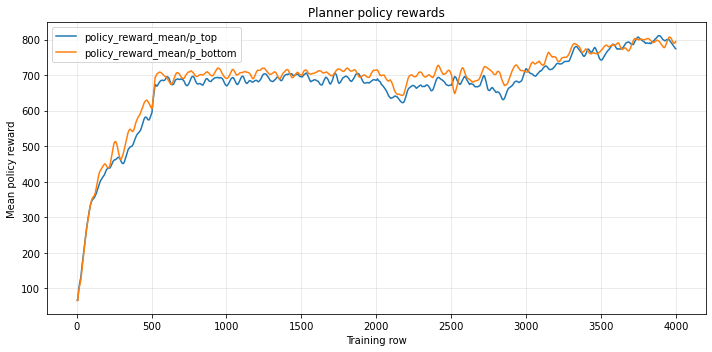

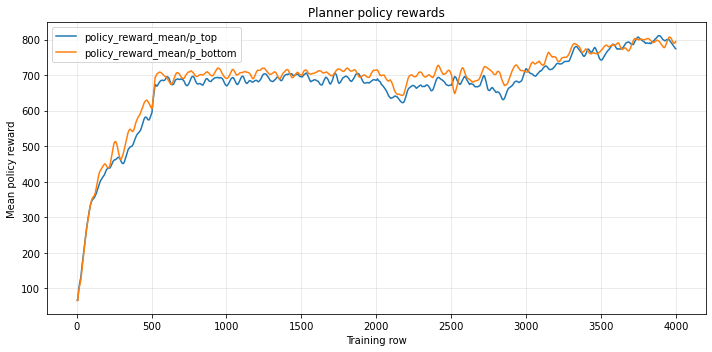

In [49]:
plot_planner_rewards(runs[1])

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original,Base,733.375,109.129131,233.87375,755,365,5867.0,0,4,4,travel-off__regionaltrade-on__layout-stacked_5...,500,1500,500,1500
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade,Whith Trade,914.000,114.003476,297.86000,1303,422,7312.0,0,4,4,travel-off__regionaltrade-off__layout-stacked_...,500,1500,500,1500
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__with_travel,With travel,908.250,83.593257,308.14250,1675,395,7266.0,79,3,5,travel-on__regionaltrade-off__layout-stacked_5...,500,1500,500,1500


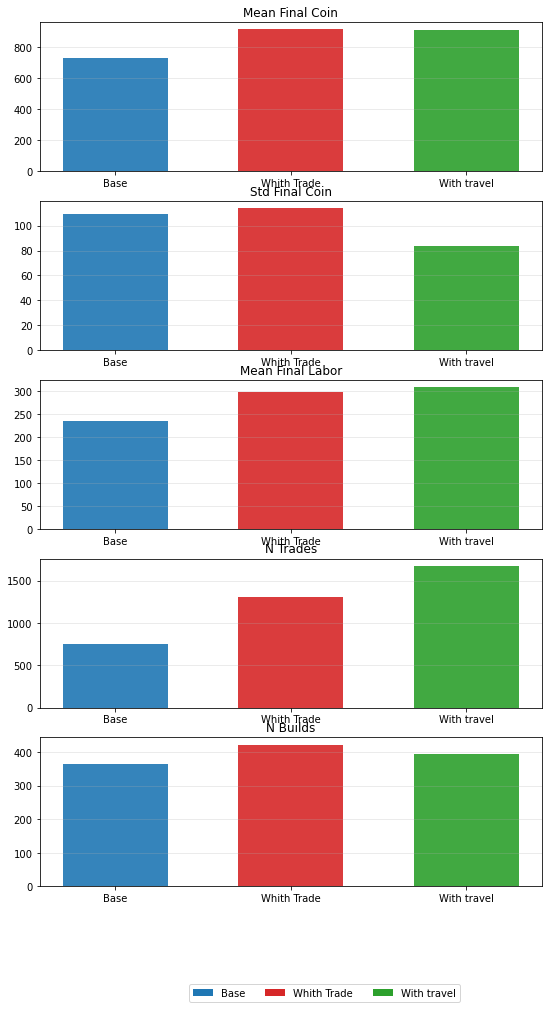

In [51]:
fig_single, out_single = plotting.compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar=None,  
)

out_single

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original,Base,733.375,109.129131,233.87375,755,365,5867.0,0,4,4,travel-off__regionaltrade-on__layout-stacked_5...,500,1500,500,1500
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade,Whith Trade,914.000,114.003476,297.86000,1303,422,7312.0,0,4,4,travel-off__regionaltrade-off__layout-stacked_...,500,1500,500,1500
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__with_travel,With travel,908.250,83.593257,308.14250,1675,395,7266.0,79,3,5,travel-on__regionaltrade-off__layout-stacked_5...,500,1500,500,1500


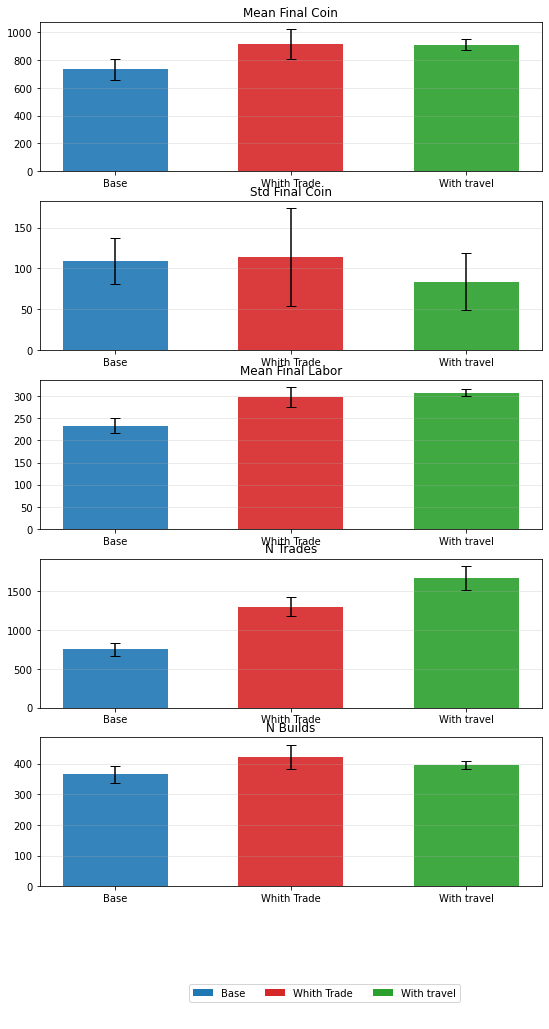

In [52]:
fig_avg, out_avg = plotting.compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar="std",  
)

out_avg

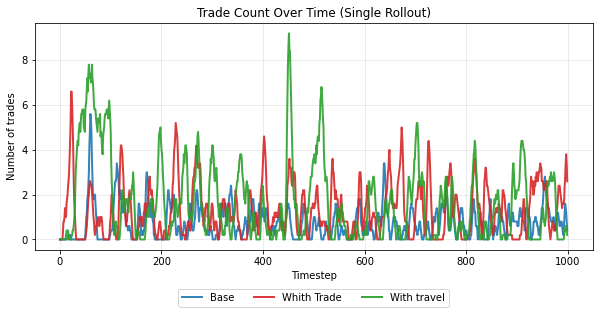

In [53]:
fig_single = plotting.compare_trade_dynamics(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    mode="single",
    smooth_window=5,  
)

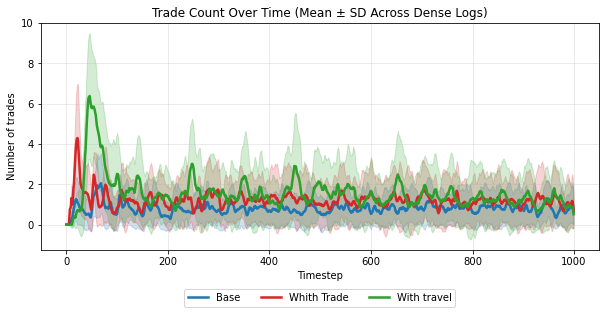

In [55]:
fig_avg = plotting.compare_trade_dynamics(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    mode="average",
    smooth_window=5,
)

,label,gini,error,n_dense_logs
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original,Base,0.083848,NaN,1
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade,Whith Trade,0.067655,NaN,1
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__with_travel,With travel,0.051598,NaN,1


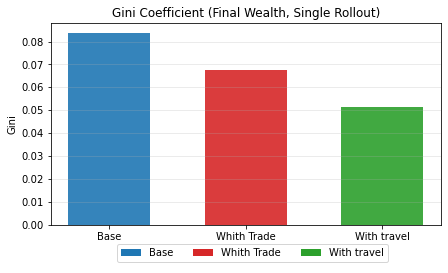

In [56]:
fig_single, out_single = plotting.compare_gini(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    mode="single",
    errorbar=None,
)

out_single

,label,gini,error,n_dense_logs
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original,Base,0.081157,0.025311,20
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade,Whith Trade,0.098910,0.040942,20
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__with_travel,With travel,0.092141,0.021422,20


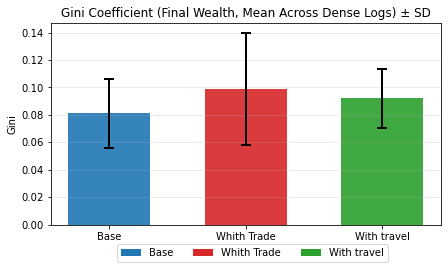

In [57]:
fig_avg, out_avg = plotting.compare_gini(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    mode="average",
    errorbar="std",
)

out_avg

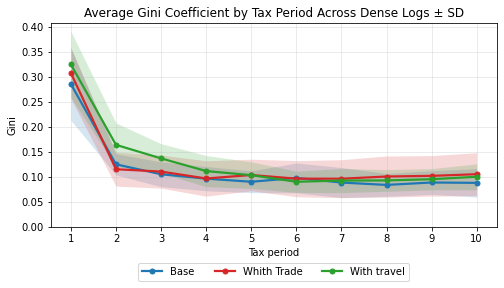

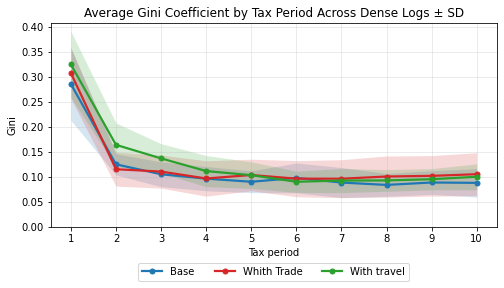

In [59]:
import importlib
importlib.reload(plotting)

runs = plotting.load_experiment_runs(run_dirs)

fig_gini_periods, gini_periods, gini_periods_raw = plotting.compare_gini_over_tax_periods(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    period=100,
    max_periods=10,
    errorbar="std",
    show_legend=True,
)

#gini_periods
fig_gini_periods



In [60]:
usd_scaling = 1000
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling

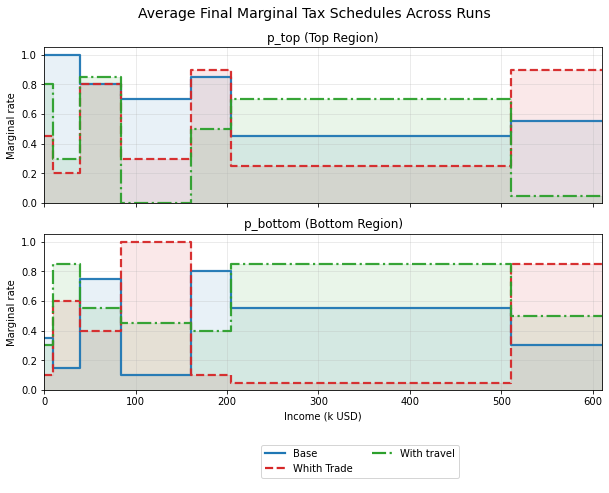

In [61]:
runs_single = []
for r in runs:
    r_copy = r.copy()
    r_copy["dense_logs"] = {0: r["dense_log"]}  # only one log
    runs_single.append(r_copy)

fig_single, out_single = plotting.compare_avg_final_tax_schedules_two_planners(
    runs_single,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar=None,  
    last_bin_width=100,
)

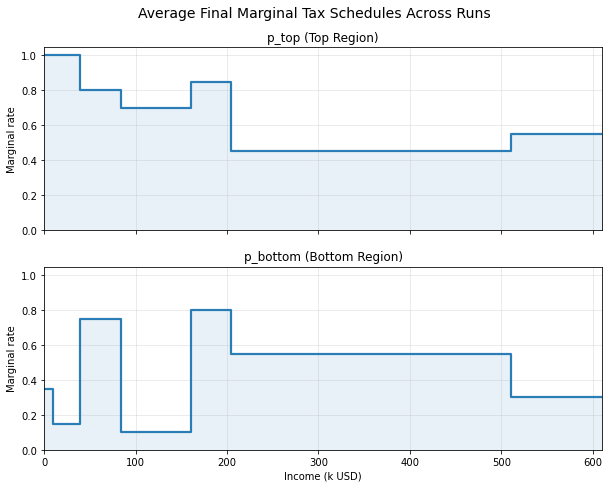

In [62]:
runs_single_no_compare = []

r_copy = runs[0].copy()
r_copy["dense_logs"] = {0: runs[0]["dense_log"]}
runs_single_no_compare.append(r_copy)

fig_single, out_single = plotting.compare_avg_final_tax_schedules_two_planners(
    runs_single_no_compare,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    #short_labels=["No travel"],
    show_legend=False,
    errorbar=None,
    last_bin_width=100,
)

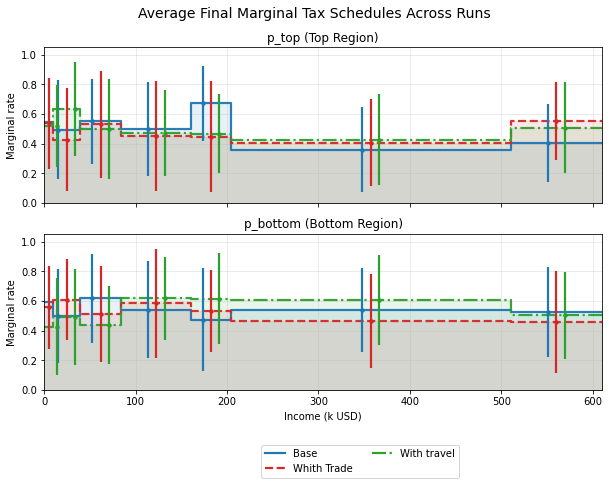

In [64]:
fig_avg, out_avg = plotting.compare_avg_final_tax_schedules_two_planners(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar="std",  
    last_bin_width=100,
)


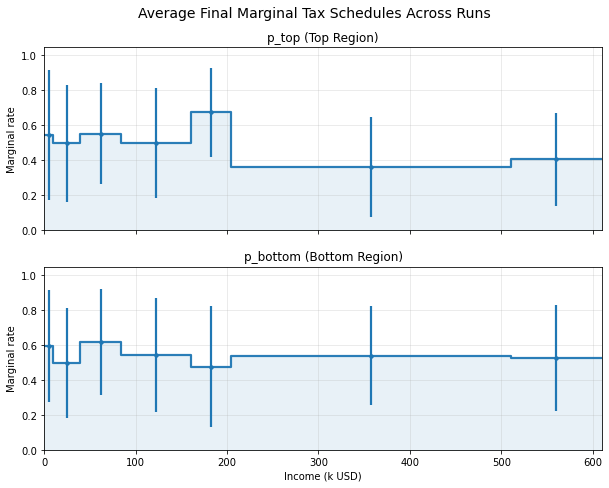

In [65]:
fig_avg, out_avg = plotting.compare_avg_final_tax_schedules_two_planners(
    [runs[0]],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    show_legend=False,
    errorbar="std",  
    last_bin_width=100,
)

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from simulation import get_disc_rates

def plot_individual_final_tax_schedules(
    runs,
    env_obj,
    brackets,
    selected=None,          # None = all dense logs; or [(run_idx, log_key), ...]
    top_first=True,
    short_labels=None,
    last_bin_width=100,
    figsize=(10, 7),
):
    disc_rates = get_disc_rates(env_obj)
    brackets = np.asarray(brackets, dtype=float)

    right_edge = brackets[-1] + last_bin_width
    step_x = np.append(brackets, right_edge)

    colors = plt.cm.tab20(np.linspace(0, 1, 20))

    def extract_logs(run):
        if "dense_logs" in run:
            obj = run["dense_logs"]
        elif "dense_log" in run:
            obj = {0: run["dense_log"]}
        else:
            return {}

        if isinstance(obj, dict):
            return obj
        if isinstance(obj, list):
            return {i: log for i, log in enumerate(obj)}
        return {}

    def split_last(arr):
        last = np.asarray(arr)[-1]
        half = last.shape[0] // 2
        if top_first:
            return last[:half], last[half:]
        else:
            return last[half:], last[:half]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    plot_i = 0

    for run_idx, run in enumerate(runs):
        logs = extract_logs(run)

        run_label = (
            short_labels[run_idx]
            if short_labels is not None
            else run.get("name", f"run {run_idx}")
        )

        for log_key, dense_log in logs.items():
            if selected is not None and (run_idx, log_key) not in selected:
                continue

            planner_actions = dense_log["planner_actions"]

            top_actions, _ = split_last(planner_actions["p_top"])
            _, bottom_actions = split_last(planner_actions["p_bottom"])

            top_rates = disc_rates[np.clip(top_actions.astype(int), 0, len(disc_rates) - 1)]
            bottom_rates = disc_rates[np.clip(bottom_actions.astype(int), 0, len(disc_rates) - 1)]

            top_step_y = np.append(top_rates, top_rates[-1])
            bottom_step_y = np.append(bottom_rates, bottom_rates[-1])

            color = colors[plot_i % len(colors)]
            label = f"{run_label}, log {log_key}"

            axes[0].step(step_x, top_step_y, where="post", color=color, linewidth=1.8, label=label)
            axes[1].step(step_x, bottom_step_y, where="post", color=color, linewidth=1.8, label=label)

            plot_i += 1

    axes[0].set_title("p_top final tax schedules")
    axes[0].set_ylabel("Marginal rate")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title("p_bottom final tax schedules")
    axes[1].set_xlabel("Income")
    axes[1].set_ylabel("Marginal rate")
    axes[1].grid(True, alpha=0.3)

    axes[1].set_xlim(brackets[0], right_edge)

    fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=2, fontsize=9)
    fig.subplots_adjust(bottom=0.22, top=0.92)

    return fig
 

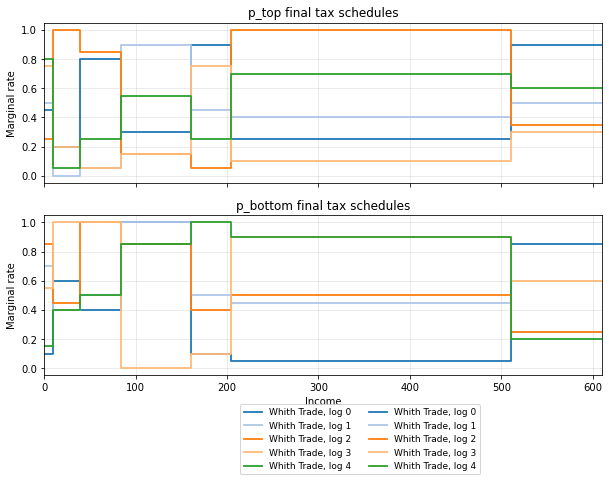

In [ ]:
fig = plot_individual_final_tax_schedules(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    selected=[
        (0, 0),   # run 0, dense log key 0
        (0, 1),   # run 0, dense log key 1
        (0, 2),   # run 0, dense log key 2
        (0, 3),   # run 0, dense log key 3
        (0, 4),   # run 0, dense log key 4
    ],
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    last_bin_width=100,
)


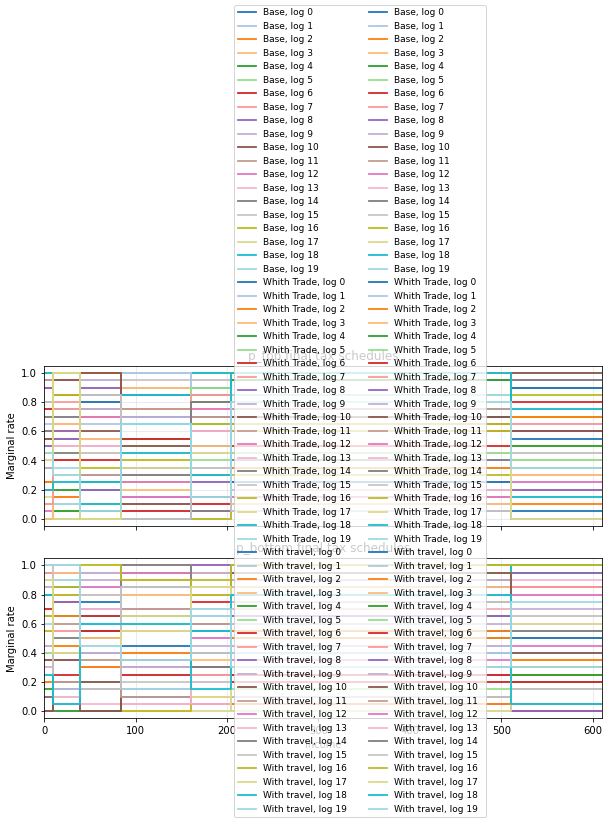

In [70]:
fig = plot_individual_final_tax_schedules(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    last_bin_width=100,
)


# same run comparison

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simulation import get_disc_rates


def _extract_logs_from_run(run):
    if "dense_logs" in run:
        obj = run["dense_logs"]
    elif "dense_log" in run:
        obj = {0: run["dense_log"]}
    else:
        return {}

    if isinstance(obj, dict):
        return obj
    if isinstance(obj, list):
        return {i: log for i, log in enumerate(obj)}
    return {}


def _numeric_agent_ids(log):
    return sorted(
        int(k) for k, v in log["states"][0].items()
        if str(k).isdigit() and isinstance(v, dict) and "loc" in v
    )


def _infer_waterline(log):
    for world_state in log.get("world", []):
        if not world_state:
            continue
        for arr in world_state.values():
            try:
                shape = np.asarray(arr).shape
            except Exception:
                continue
            if len(shape) >= 2 and shape[0] > 0:
                return int(shape[0] // 2)
    return 25


def _planner_region_from_initial_state(log, aid, waterline=None):
    if waterline is None:
        waterline = _infer_waterline(log)

    s0 = log["states"][0][str(aid)]
    row0 = int(s0["loc"][0])

    # Matches regional_two_planner.py:
    # p_top if initial row <= waterline, else p_bottom
    return "top" if row0 <= waterline else "bottom"


def _location_region_from_state(s, waterline):
    row = int(s["loc"][0])
    return "top" if row <= waterline else "bottom"


def _coin(s):
    return float(s["inventory"].get("Coin", 0.0)) + float(s["escrow"].get("Coin", 0.0))


def _resource_total(s, resource):
    return float(s["inventory"].get(resource, 0.0)) + float(s["escrow"].get(resource, 0.0))


def _movement_distance(log, aid):
    locs = np.array([st[str(aid)]["loc"] for st in log["states"]], dtype=float)
    if len(locs) <= 1:
        return 0.0
    return float(np.abs(np.diff(locs, axis=0)).sum())


def _region_switches(log, aid, waterline=None):
    if waterline is None:
        waterline = _infer_waterline(log)

    regions = [
        _location_region_from_state(st[str(aid)], waterline=waterline)
        for st in log["states"]
    ]
    return int(sum(regions[i] != regions[i - 1] for i in range(1, len(regions))))


def _build_income_by_agent(log):
    out = {}
    for builds in log.get("Build", []):
        builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
        for b in builds_:
            aid = int(b["builder"])
            out[aid] = out.get(aid, 0.0) + float(b.get("income", 0.0))
    return out


def _trade_income_by_agent(log):
    sell_income = {}
    buy_cost = {}

    for trades in log.get("Trade", []):
        trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
        for tr in trades_:
            seller = int(tr["seller"])
            buyer = int(tr["buyer"])

            sell_income[seller] = sell_income.get(seller, 0.0) + float(
                tr.get("income", tr.get("price", 0.0))
            )
            buy_cost[buyer] = buy_cost.get(buyer, 0.0) + float(
                tr.get("cost", tr.get("price", 0.0))
            )

    return sell_income, buy_cost


def _agent_behavior_table(log):
    aids = _numeric_agent_ids(log)
    waterline = _infer_waterline(log)

    build_income = _build_income_by_agent(log)
    sell_income, buy_cost = _trade_income_by_agent(log)

    rows = []
    for aid in aids:
        s0 = log["states"][0][str(aid)]
        s1 = log["states"][-1][str(aid)]

        rows.append({
            "agent": aid,
            "skill_build_payment": float(s0.get("build_payment", np.nan)),
            "gather_bonus": float(s0.get("bonus_gather_prob", np.nan)),

            # Fixed tax/planner assignment. This is the important grouping.
            "planner_region": _planner_region_from_initial_state(log, aid, waterline=waterline),

            # Physical location regions, useful for travel diagnostics.
            "start_location_region": _location_region_from_state(s0, waterline=waterline),
            "final_location_region": _location_region_from_state(s1, waterline=waterline),

            "final_coin": _coin(s1),
            "coin_change": _coin(s1) - _coin(s0),
            "final_wood": _resource_total(s1, "Wood"),
            "final_stone": _resource_total(s1, "Stone"),
            "final_labor": float(s1.get("endogenous", {}).get("Labor", np.nan)),
            "final_utility": float(s1.get("utility", np.nan)),
            "build_income": build_income.get(aid, 0.0),
            "sell_income": sell_income.get(aid, 0.0),
            "buy_cost": buy_cost.get(aid, 0.0),
            "total_income": build_income.get(aid, 0.0) + sell_income.get(aid, 0.0),
            "net_market": sell_income.get(aid, 0.0) - buy_cost.get(aid, 0.0),
            "move_distance": _movement_distance(log, aid),
            "region_switches": _region_switches(log, aid, waterline=waterline),
        })

    return pd.DataFrame(rows)


def _final_tax_rates(log, env_obj, top_first=True):
    disc_rates = get_disc_rates(env_obj)

    def split_last(arr):
        last = np.asarray(arr)[-1]
        half = last.shape[0] // 2
        if top_first:
            return last[:half], last[half:]
        else:
            return last[half:], last[:half]

    planner_actions = log["planner_actions"]

    top_actions, _ = split_last(planner_actions["p_top"])
    _, bottom_actions = split_last(planner_actions["p_bottom"])

    top_rates = disc_rates[np.clip(top_actions.astype(int), 0, len(disc_rates) - 1)]
    bottom_rates = disc_rates[np.clip(bottom_actions.astype(int), 0, len(disc_rates) - 1)]

    return top_rates, bottom_rates


In [72]:
def plot_tax_and_agent_behavior_for_logs(
    runs,
    env_obj,
    brackets,
    selected=None,          # None = first few logs; or [(run_idx, log_key), ...]
    top_first=True,
    short_labels=None,
    last_bin_width=100,
    max_logs=6,
    behavior_metric="total_income",
    figsize_per_log=(13, 3.2),
):
    brackets = np.asarray(brackets, dtype=float)
    step_x = np.append(brackets, brackets[-1] + last_bin_width)

    available = []
    selected_set = set(selected) if selected is not None else None

    for run_idx, run in enumerate(runs):
        logs = _extract_logs_from_run(run)
        for log_key, log in logs.items():
            if selected_set is None or (run_idx, log_key) in selected_set:
                available.append((run_idx, log_key, run, log))

    if selected is None:
        available = available[:max_logs]

    n = len(available)
    if n == 0:
        raise ValueError("No dense logs selected/found.")

    fig, axes = plt.subplots(
        n,
        4,
        figsize=(figsize_per_log[0], figsize_per_log[1] * n),
        squeeze=False,
    )

    region_colors = {"top": "#1f77b4", "bottom": "#ff7f0e"}

    for row, (run_idx, log_key, run, log) in enumerate(available):
        run_label = (
            short_labels[run_idx]
            if short_labels is not None
            else run.get("name", f"run {run_idx}")
        )

        top_rates, bottom_rates = _final_tax_rates(log, env_obj, top_first=top_first)
        top_step_y = np.append(top_rates, top_rates[-1])
        bottom_step_y = np.append(bottom_rates, bottom_rates[-1])

        df_agents = _agent_behavior_table(log)
        df_agents = df_agents.sort_values(["planner_region", "skill_build_payment", "agent"])

        # 1. Top tax schedule
        ax = axes[row, 0]
        ax.step(step_x, top_step_y, where="post", color="#1f77b4", linewidth=2)
        ax.set_title(f"{run_label}, log {log_key}\np_top tax")
        ax.set_ylim(0, max(1.0, top_step_y.max() * 1.05))
        ax.grid(True, alpha=0.3)

        # 2. Bottom tax schedule
        ax = axes[row, 1]
        ax.step(step_x, bottom_step_y, where="post", color="#ff7f0e", linewidth=2)
        ax.set_title("p_bottom tax")
        ax.set_ylim(0, max(1.0, bottom_step_y.max() * 1.05))
        ax.grid(True, alpha=0.3)

        # 3. Agent behavior bars, colored by fixed planner/tax region
        ax = axes[row, 2]
        colors = [region_colors.get(r, "gray") for r in df_agents["planner_region"]]
        labels = [
            f"{int(a)} ({pr[0]}->{lr[0]})"
            for a, pr, lr in zip(
                df_agents["agent"],
                df_agents["planner_region"],
                df_agents["final_location_region"],
            )
        ]

        ax.bar(labels, df_agents[behavior_metric], color=colors, alpha=0.85)
        ax.set_title(f"Agent {behavior_metric}\nlabel = agent (planner->final loc)")
        ax.set_xlabel("agent")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, axis="y", alpha=0.3)

        # 4. Coin/labor scatter, colored by fixed planner/tax region
        ax = axes[row, 3]
        colors = [region_colors.get(r, "gray") for r in df_agents["planner_region"]]

        skill = df_agents["skill_build_payment"]
        if skill.notna().any() and skill.max() > skill.min():
            sizes = 40 + 100 * ((skill - skill.min()) / (skill.max() - skill.min()))
        else:
            sizes = np.full(len(df_agents), 70)

        ax.scatter(
            df_agents["final_labor"],
            df_agents["final_coin"],
            c=colors,
            s=sizes,
            alpha=0.8,
            edgecolor="black",
            linewidth=0.5,
        )

        for _, r in df_agents.iterrows():
            ax.annotate(
                str(int(r["agent"])),
                (r["final_labor"], r["final_coin"]),
                fontsize=8,
            )

        ax.set_title("Final coin vs labor\ncolor = fixed planner region")
        ax.set_xlabel("final labor")
        ax.set_ylabel("final coin")
        ax.grid(True, alpha=0.3)

        # Print counts so assignment issues are visible immediately
        print(f"{run_label}, log {log_key}")
        print("planner_region counts:")
        print(df_agents["planner_region"].value_counts(dropna=False).to_string())
        print("final_location_region counts:")
        print(df_agents["final_location_region"].value_counts(dropna=False).to_string())
        print()

    fig.tight_layout()
    return fig


No travel, log 16
planner_region counts:
bottom    4
top       4
final_location_region counts:
bottom    4
top       4

No travel, log 18
planner_region counts:
bottom    4
top       4
final_location_region counts:
bottom    4
top       4



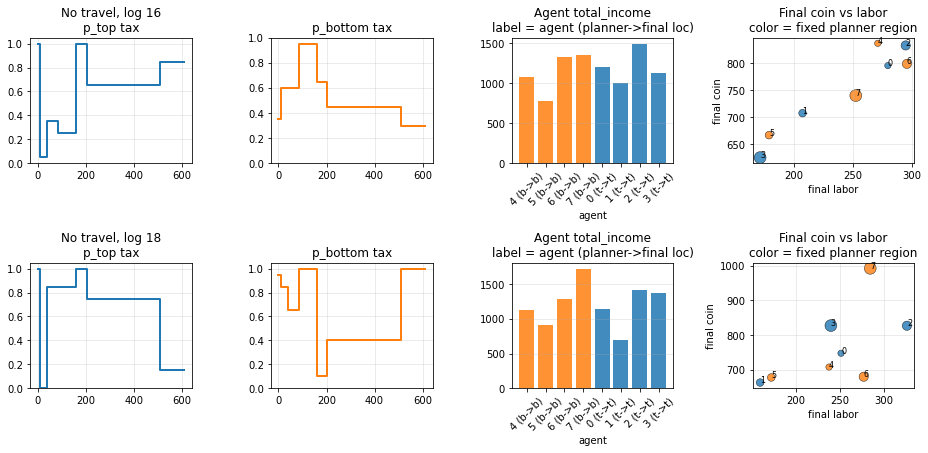

In [73]:
fig = plot_tax_and_agent_behavior_for_logs(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    selected=[
        (0, 16),
        (0, 18),
        # (1, 2),
    ],
    top_first=True,
    short_labels=["No travel", "With travel"],
    behavior_metric="total_income",   # try: final_coin, final_labor, move_distance, region_switches
    last_bin_width=100,
)

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from simulation import get_disc_rates


def _extract_logs_from_run(run):
    if "dense_logs" in run:
        obj = run["dense_logs"]
    elif "dense_log" in run:
        obj = {0: run["dense_log"]}
    else:
        return {}

    if isinstance(obj, dict):
        return obj
    if isinstance(obj, list):
        return {i: log for i, log in enumerate(obj)}
    return {}


def _numeric_agent_ids(log):
    return sorted(
        int(k) for k, v in log["states"][0].items()
        if str(k).isdigit() and isinstance(v, dict) and "loc" in v
    )


def _infer_waterline(log):
    for world_state in log.get("world", []):
        if not world_state:
            continue
        for arr in world_state.values():
            try:
                shape = np.asarray(arr).shape
            except Exception:
                continue
            if len(shape) >= 2 and shape[0] > 0:
                return int(shape[0] // 2)
    return 25


def _location_region_from_state(s, waterline):
    row = int(s["loc"][0])
    return "top" if row <= waterline else "bottom"


def _planner_region_from_initial_state(log, aid, waterline=None):
    if waterline is None:
        waterline = _infer_waterline(log)
    s0 = log["states"][0][str(aid)]
    row0 = int(s0["loc"][0])
    return "top" if row0 <= waterline else "bottom"


def _coin(s):
    return float(s["inventory"].get("Coin", 0.0)) + float(s["escrow"].get("Coin", 0.0))


def _resource_total(s, resource):
    return float(s["inventory"].get(resource, 0.0)) + float(s["escrow"].get(resource, 0.0))


def _movement_distance(log, aid):
    locs = np.array([st[str(aid)]["loc"] for st in log["states"]], dtype=float)
    if len(locs) <= 1:
        return 0.0
    return float(np.abs(np.diff(locs, axis=0)).sum())


def _region_sequence(log, aid, waterline=None):
    if waterline is None:
        waterline = _infer_waterline(log)
    return [
        _location_region_from_state(st[str(aid)], waterline=waterline)
        for st in log["states"]
    ]


def _region_shares(log, aid, waterline=None):
    regions = _region_sequence(log, aid, waterline=waterline)
    n = max(1, len(regions))
    share_top = sum(r == "top" for r in regions) / n
    share_bottom = sum(r == "bottom" for r in regions) / n
    switches = sum(regions[i] != regions[i - 1] for i in range(1, len(regions)))
    majority = "top" if share_top >= share_bottom else "bottom"
    return share_top, share_bottom, majority, int(switches)


def _build_income_by_agent(log):
    out = {}
    for builds in log.get("Build", []):
        builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
        for b in builds_:
            aid = int(b["builder"])
            out[aid] = out.get(aid, 0.0) + float(b.get("income", 0.0))
    return out


def _trade_income_by_agent(log):
    sell_income = {}
    buy_cost = {}

    for trades in log.get("Trade", []):
        trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
        for tr in trades_:
            seller = int(tr["seller"])
            buyer = int(tr["buyer"])

            sell_income[seller] = sell_income.get(seller, 0.0) + float(
                tr.get("income", tr.get("price", 0.0))
            )
            buy_cost[buyer] = buy_cost.get(buyer, 0.0) + float(
                tr.get("cost", tr.get("price", 0.0))
            )

    return sell_income, buy_cost


def _agent_behavior_table(log):
    aids = _numeric_agent_ids(log)
    waterline = _infer_waterline(log)

    build_income = _build_income_by_agent(log)
    sell_income, buy_cost = _trade_income_by_agent(log)

    rows = []
    for aid in aids:
        s0 = log["states"][0][str(aid)]
        s1 = log["states"][-1][str(aid)]

        share_top, share_bottom, majority_region, switches = _region_shares(
            log, aid, waterline=waterline
        )

        rows.append({
            "agent": aid,
            "skill_build_payment": float(s0.get("build_payment", np.nan)),
            "gather_bonus": float(s0.get("bonus_gather_prob", np.nan)),

            "planner_region": _planner_region_from_initial_state(log, aid, waterline=waterline),
            "start_location_region": _location_region_from_state(s0, waterline=waterline),
            "final_location_region": _location_region_from_state(s1, waterline=waterline),
            "majority_location_region": majority_region,
            "share_top": share_top,
            "share_bottom": share_bottom,
            "region_switches": switches,

            "final_coin": _coin(s1),
            "coin_change": _coin(s1) - _coin(s0),
            "final_wood": _resource_total(s1, "Wood"),
            "final_stone": _resource_total(s1, "Stone"),
            "final_labor": float(s1.get("endogenous", {}).get("Labor", np.nan)),
            "final_utility": float(s1.get("utility", np.nan)),
            "build_income": build_income.get(aid, 0.0),
            "sell_income": sell_income.get(aid, 0.0),
            "buy_cost": buy_cost.get(aid, 0.0),
            "total_income": build_income.get(aid, 0.0) + sell_income.get(aid, 0.0),
            "net_market": sell_income.get(aid, 0.0) - buy_cost.get(aid, 0.0),
            "move_distance": _movement_distance(log, aid),
        })

    return pd.DataFrame(rows)


def _split_last_tax_action(arr, top_first=True):
    last = np.asarray(arr)[-1]
    half = last.shape[0] // 2
    if top_first:
        return last[:half], last[half:]
    return last[half:], last[:half]


def _split_tax_action_matrix(arr, top_first=True):
    arr = np.asarray(arr)
    half = arr.shape[1] // 2
    if top_first:
        return arr[:, :half], arr[:, half:]
    return arr[:, half:], arr[:, :half]


def _final_tax_rates(log, env_obj, top_first=True):
    disc_rates = get_disc_rates(env_obj)
    planner_actions = log["planner_actions"]

    top_actions, _ = _split_last_tax_action(planner_actions["p_top"], top_first=top_first)
    _, bottom_actions = _split_last_tax_action(planner_actions["p_bottom"], top_first=top_first)

    top_rates = disc_rates[np.clip(top_actions.astype(int), 0, len(disc_rates) - 1)]
    bottom_rates = disc_rates[np.clip(bottom_actions.astype(int), 0, len(disc_rates) - 1)]

    return top_rates, bottom_rates


def _tax_rate_matrices(log, env_obj, top_first=True):
    disc_rates = get_disc_rates(env_obj)

    ptop_actions = np.asarray(log["planner_actions"]["p_top"])
    pbot_actions = np.asarray(log["planner_actions"]["p_bottom"])

    ptop_top, _ = _split_tax_action_matrix(ptop_actions, top_first=top_first)
    _, pbot_bottom = _split_tax_action_matrix(pbot_actions, top_first=top_first)

    ptop_rates = disc_rates[np.clip(ptop_top.astype(int), 0, len(disc_rates) - 1)]
    pbot_rates = disc_rates[np.clip(pbot_bottom.astype(int), 0, len(disc_rates) - 1)]

    return ptop_rates, pbot_rates


def _period_income_table(log, period=100):
    states = log["states"]
    aids = _numeric_agent_ids(log)
    waterline = _infer_waterline(log)

    tax_days = list(range(period - 1, len(states), period))
    prev_idx = 0

    rows = []
    for tax_day_number, t in enumerate(tax_days, start=1):
        for aid in aids:
            s_prev = states[prev_idx][str(aid)]
            s_now = states[t][str(aid)]

            rows.append({
                "tax_day_number": tax_day_number,
                "timestep": t,
                "agent": aid,
                "planner_region": _planner_region_from_initial_state(log, aid, waterline=waterline),
                "location_region": _location_region_from_state(s_now, waterline=waterline),
                "income": _coin(s_now) - _coin(s_prev),
                "coin_end": _coin(s_now),
                "labor_end": float(s_now.get("endogenous", {}).get("Labor", np.nan)),
            })

        prev_idx = t

    return pd.DataFrame(rows)


def _bracket_labels_from_cutoffs(cutoffs):
    labels = []
    for lo, hi in zip(cutoffs[:-1], cutoffs[1:]):
        lo_s = "-inf" if np.isneginf(lo) else f"{lo:g}"
        hi_s = "inf" if np.isposinf(hi) else f"{hi:g}"
        labels.append(f"[{lo_s}, {hi_s})")
    return labels


def _income_bracket_counts(log, brackets, period=100):
    df = _period_income_table(log, period=period)

    brackets = np.asarray(brackets, dtype=float)
    cutoffs = np.r_[-np.inf, brackets[1:], np.inf]
    labels = _bracket_labels_from_cutoffs(cutoffs)

    df["tax_bracket"] = pd.cut(
        df["income"],
        bins=cutoffs,
        labels=labels,
        right=False,
        include_lowest=True,
    )

    counts = (
        df.groupby(["tax_day_number", "planner_region", "tax_bracket"], observed=False)
        .size()
        .reset_index(name="n_agents")
    )

    return df, counts, labels


No travel, log 0
planner_region counts:
bottom    4
top       4
majority_location_region counts:
bottom    4
top       4
final_location_region counts:
bottom    4
top       4



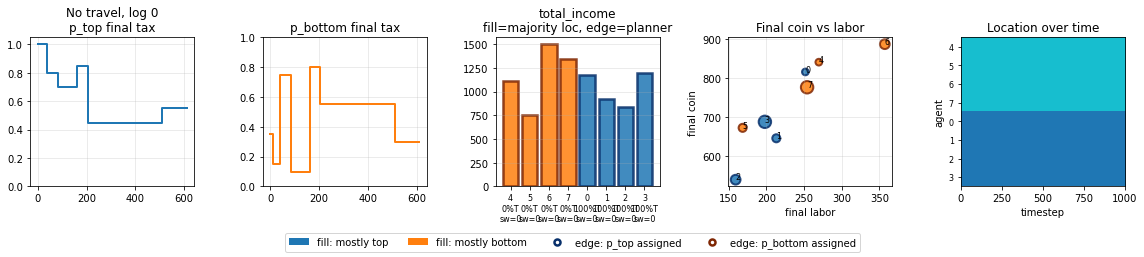

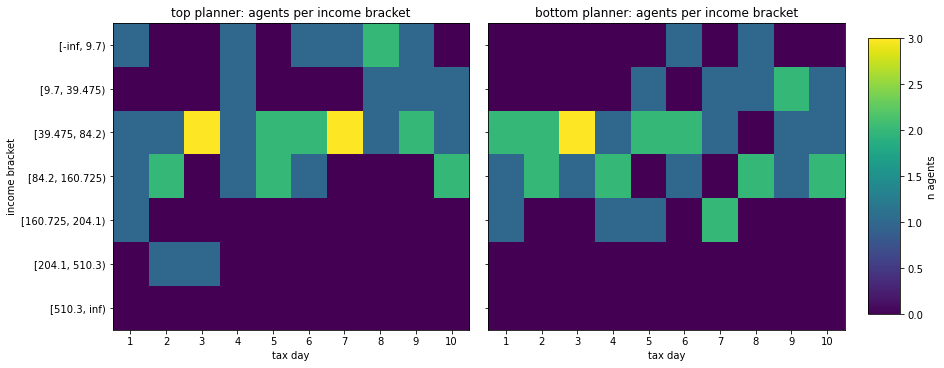

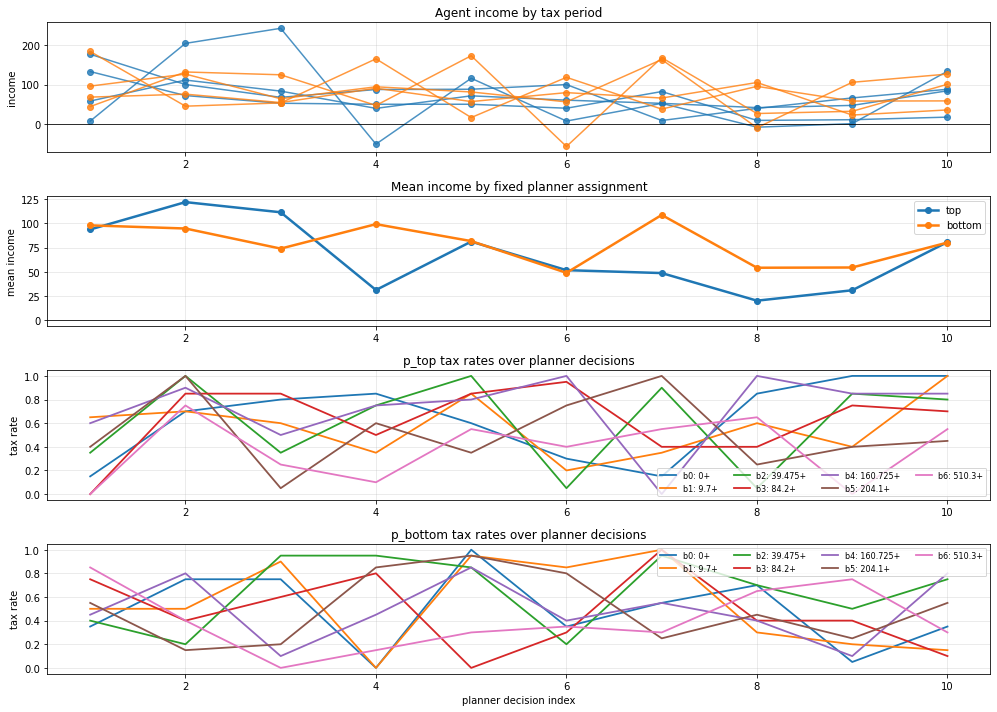

In [75]:
def plot_tax_and_agent_behavior_for_logs_v2(
    runs,
    env_obj,
    brackets,
    selected=None,
    top_first=True,
    short_labels=None,
    last_bin_width=100,
    max_logs=4,
    behavior_metric="total_income",
    figsize_per_log=(16, 3.6),
):
    brackets = np.asarray(brackets, dtype=float)
    step_x = np.append(brackets, brackets[-1] + last_bin_width)

    available = []
    selected_set = set(selected) if selected is not None else None

    for run_idx, run in enumerate(runs):
        logs = _extract_logs_from_run(run)
        for log_key, log in logs.items():
            if selected_set is None or (run_idx, log_key) in selected_set:
                available.append((run_idx, log_key, run, log))

    if selected is None:
        available = available[:max_logs]

    if len(available) == 0:
        raise ValueError("No dense logs selected/found.")

    region_colors = {"top": "#1f77b4", "bottom": "#ff7f0e"}
    edge_colors = {"top": "#08306b", "bottom": "#7f2704"}

    fig, axes = plt.subplots(
        len(available),
        5,
        figsize=(figsize_per_log[0], figsize_per_log[1] * len(available)),
        squeeze=False,
    )

    for row, (run_idx, log_key, run, log) in enumerate(available):
        run_label = (
            short_labels[run_idx]
            if short_labels is not None
            else run.get("name", f"run {run_idx}")
        )

        top_rates, bottom_rates = _final_tax_rates(log, env_obj, top_first=top_first)
        top_step_y = np.append(top_rates, top_rates[-1])
        bottom_step_y = np.append(bottom_rates, bottom_rates[-1])

        df_agents = _agent_behavior_table(log)
        df_agents = df_agents.sort_values(["planner_region", "skill_build_payment", "agent"])

        # 1. p_top final tax
        ax = axes[row, 0]
        ax.step(step_x, top_step_y, where="post", color=region_colors["top"], linewidth=2)
        ax.set_title(f"{run_label}, log {log_key}\np_top final tax")
        ax.set_ylim(0, max(1.0, top_step_y.max() * 1.05))
        ax.grid(True, alpha=0.3)

        # 2. p_bottom final tax
        ax = axes[row, 1]
        ax.step(step_x, bottom_step_y, where="post", color=region_colors["bottom"], linewidth=2)
        ax.set_title("p_bottom final tax")
        ax.set_ylim(0, max(1.0, bottom_step_y.max() * 1.05))
        ax.grid(True, alpha=0.3)

        # 3. behavior bars
        ax = axes[row, 2]
        fill = [region_colors.get(r, "gray") for r in df_agents["majority_location_region"]]
        edge = [edge_colors.get(r, "black") for r in df_agents["planner_region"]]

        labels = [
            f"{int(a)}\n{st:.0%}T\nsw={int(sw)}"
            for a, st, sw in zip(
                df_agents["agent"],
                df_agents["share_top"],
                df_agents["region_switches"],
            )
        ]

        bars = ax.bar(labels, df_agents[behavior_metric], color=fill, alpha=0.85)
        for bar, ec in zip(bars, edge):
            bar.set_edgecolor(ec)
            bar.set_linewidth(2.5)

        ax.set_title(f"{behavior_metric}\nfill=majority loc, edge=planner")
        ax.tick_params(axis="x", rotation=0, labelsize=8)
        ax.grid(True, axis="y", alpha=0.3)

        # 4. coin/labor scatter
        ax = axes[row, 3]
        fill = [region_colors.get(r, "gray") for r in df_agents["majority_location_region"]]
        edge = [edge_colors.get(r, "black") for r in df_agents["planner_region"]]

        skill = df_agents["skill_build_payment"]
        if skill.notna().any() and skill.max() > skill.min():
            sizes = 45 + 110 * ((skill - skill.min()) / (skill.max() - skill.min()))
        else:
            sizes = np.full(len(df_agents), 75)

        ax.scatter(
            df_agents["final_labor"],
            df_agents["final_coin"],
            c=fill,
            edgecolor=edge,
            s=sizes,
            linewidth=2,
            alpha=0.85,
        )

        for _, r in df_agents.iterrows():
            ax.annotate(str(int(r["agent"])), (r["final_labor"], r["final_coin"]), fontsize=8)

        ax.set_title("Final coin vs labor")
        ax.set_xlabel("final labor")
        ax.set_ylabel("final coin")
        ax.grid(True, alpha=0.3)

        # 5. region timeline heatmap
        ax = axes[row, 4]
        aids = df_agents["agent"].astype(int).tolist()
        waterline = _infer_waterline(log)

        region_mat = []
        for aid in aids:
            seq = _region_sequence(log, aid, waterline=waterline)
            region_mat.append([0 if r == "top" else 1 for r in seq])

        region_mat = np.asarray(region_mat)
        ax.imshow(region_mat, aspect="auto", interpolation="nearest", cmap=plt.cm.get_cmap("tab10", 2))
        ax.set_yticks(np.arange(len(aids)))
        ax.set_yticklabels([str(a) for a in aids], fontsize=8)
        ax.set_title("Location over time")
        ax.set_xlabel("timestep")
        ax.set_ylabel("agent")

        print(f"{run_label}, log {log_key}")
        print("planner_region counts:")
        print(df_agents["planner_region"].value_counts(dropna=False).to_string())
        print("majority_location_region counts:")
        print(df_agents["majority_location_region"].value_counts(dropna=False).to_string())
        print("final_location_region counts:")
        print(df_agents["final_location_region"].value_counts(dropna=False).to_string())
        print()

    legend_handles = [
        Patch(facecolor=region_colors["top"], label="fill: mostly top"),
        Patch(facecolor=region_colors["bottom"], label="fill: mostly bottom"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
               markeredgecolor=edge_colors["top"], markeredgewidth=2.5, label="edge: p_top assigned"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
               markeredgecolor=edge_colors["bottom"], markeredgewidth=2.5, label="edge: p_bottom assigned"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=True)
    fig.subplots_adjust(bottom=0.12)
    fig.tight_layout(rect=[0, 0.08, 1, 1])

    return fig


def plot_bracket_counts_for_log(
    log,
    brackets,
    period=100,
    figsize=(13, 5),
):
    df_income, counts, labels = _income_bracket_counts(log, brackets, period=period)

    fig, axes = plt.subplots(
        1, 2,
        figsize=figsize,
        sharey=True,
        constrained_layout=True,
    )

    im = None

    for ax, region in zip(axes, ["top", "bottom"]):
        pivot = (
            counts[counts["planner_region"] == region]
            .pivot(index="tax_bracket", columns="tax_day_number", values="n_agents")
            .reindex(labels)
            .fillna(0)
        )

        im = ax.imshow(
            pivot.values,
            aspect="auto",
            interpolation="nearest",
            cmap="viridis",
        )

        ax.set_title(f"{region} planner: agents per income bracket")
        ax.set_xlabel("tax day")
        ax.set_yticks(np.arange(len(labels)))
        ax.set_yticklabels(labels)
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)

    axes[0].set_ylabel("income bracket")

    # Colorbar placed outside the right edge
    cbar = fig.colorbar(im, ax=axes, location="right", shrink=0.9, pad=0.02)
    cbar.set_label("n agents")

    return fig, df_income, counts



def plot_income_and_tax_over_time(
    log,
    env_obj,
    brackets,
    period=100,
    top_first=True,
    figsize=(14, 10),
):
    df_income = _period_income_table(log, period=period)
    ptop_rates, pbot_rates = _tax_rate_matrices(log, env_obj, top_first=top_first)

    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=False)

    # 1. Agent incomes over tax periods
    ax = axes[0]
    for aid, dfa in df_income.groupby("agent"):
        planner_region = dfa["planner_region"].iloc[0]
        color = "#1f77b4" if planner_region == "top" else "#ff7f0e"
        ax.plot(dfa["tax_day_number"], dfa["income"], marker="o", linewidth=1.5, color=color, alpha=0.8, label=f"agent {aid}")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Agent income by tax period")
    ax.set_ylabel("income")
    ax.grid(True, alpha=0.3)

    # 2. Mean income by planner assignment
    ax = axes[1]
    mean_income = (
        df_income.groupby(["tax_day_number", "planner_region"])["income"]
        .mean()
        .reset_index()
    )

    for region, color in [("top", "#1f77b4"), ("bottom", "#ff7f0e")]:
        dfr = mean_income[mean_income["planner_region"] == region]
        ax.plot(dfr["tax_day_number"], dfr["income"], marker="o", linewidth=2.5, color=color, label=region)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Mean income by fixed planner assignment")
    ax.set_ylabel("mean income")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 3. p_top tax rates over planner decisions
    ax = axes[2]
    x_top = np.arange(1, ptop_rates.shape[0] + 1)
    for b in range(ptop_rates.shape[1]):
        label = f"b{b}: {brackets[b]:g}+"
        ax.plot(x_top, ptop_rates[:, b], linewidth=1.8, label=label)

    ax.set_title("p_top tax rates over planner decisions")
    ax.set_ylabel("tax rate")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=4, fontsize=8)

    # 4. p_bottom tax rates over planner decisions
    ax = axes[3]
    x_bot = np.arange(1, pbot_rates.shape[0] + 1)
    for b in range(pbot_rates.shape[1]):
        label = f"b{b}: {brackets[b]:g}+"
        ax.plot(x_bot, pbot_rates[:, b], linewidth=1.8, label=label)

    ax.set_title("p_bottom tax rates over planner decisions")
    ax.set_xlabel("planner decision index")
    ax.set_ylabel("tax rate")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=4, fontsize=8)

    fig.tight_layout()
    return fig, df_income


# -----------------------------
# Example usage
# -----------------------------

log = _extract_logs_from_run(runs[0])[0]

fig_behavior = plot_tax_and_agent_behavior_for_logs_v2(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    selected=[(0, 0)],
    top_first=True,
    short_labels=["No travel", "With travel"],
    behavior_metric="total_income",   # try final_coin, final_labor, move_distance, region_switches
    last_bin_width=100,
)

fig_brackets, df_income, df_bracket_counts = plot_bracket_counts_for_log(
    log,
    brackets=brackets,
    period=100,
)

fig_time, df_income_time = plot_income_and_tax_over_time(
    log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
)


In [76]:
def plot_tax_bracket_snapshots(
    log,
    env_obj,
    brackets,
    period=100,
    n_snapshots=10,
    top_first=True,
    figsize=None,
):
    df_income, counts, labels = _income_bracket_counts(log, brackets, period=period)
    ptop_rates, pbot_rates = _tax_rate_matrices(log, env_obj, top_first=top_first)

    tax_days = sorted(df_income["tax_day_number"].unique())
    if len(tax_days) == 0:
        raise ValueError("No tax days found.")

    if len(tax_days) <= n_snapshots:
        chosen_days = tax_days
    else:
        idx = np.linspace(0, len(tax_days) - 1, n_snapshots).round().astype(int)
        chosen_days = [tax_days[i] for i in idx]

    if figsize is None:
        figsize = (2.6 * len(chosen_days), 6.8)

    fig, axes = plt.subplots(
        2,
        len(chosen_days),
        figsize=figsize,
        sharey=True,
        constrained_layout=True,
    )

    if len(chosen_days) == 1:
        axes = np.asarray(axes).reshape(2, 1)

    bracket_x = np.arange(len(labels))
    regions = [
        ("top", ptop_rates, "#1f77b4"),
        ("bottom", pbot_rates, "#ff7f0e"),
    ]

    max_count = max(1, int(counts["n_agents"].max()))
    n_tax_days = len(tax_days)

    for row, (region, rate_matrix, color) in enumerate(regions):
        for col, tax_day in enumerate(chosen_days):
            ax = axes[row, col]

            day_counts = (
                counts[
                    (counts["planner_region"] == region)
                    & (counts["tax_day_number"] == tax_day)
                ]
                .set_index("tax_bracket")["n_agents"]
                .reindex(labels)
                .fillna(0)
            )

            if n_tax_days == 1 or rate_matrix.shape[0] == 1:
                decision_idx = 0
            else:
                frac = (tax_day - tax_days[0]) / (tax_days[-1] - tax_days[0])
                decision_idx = int(round(frac * (rate_matrix.shape[0] - 1)))

            decision_idx = min(max(decision_idx, 0), rate_matrix.shape[0] - 1)
            rates = rate_matrix[decision_idx]

            ax.bar(
                bracket_x,
                day_counts.values,
                color=color,
                alpha=0.35,
                edgecolor=color,
                linewidth=1.2,
            )

            ax.set_ylim(0, max_count + 0.5)
            ax.set_yticks(range(0, max_count + 1))

            if col == 0:
                ax.set_ylabel("n agents")
            else:
                ax.tick_params(axis="y", labelleft=False)

            ax2 = ax.twinx()
            ax2.plot(
                bracket_x,
                rates,
                color=color,
                marker="o",
                linewidth=2.0,
            )
            ax2.set_ylim(0, max(1.0, np.nanmax(rate_matrix) * 1.05))

            if col == len(chosen_days) - 1:
                ax2.set_ylabel("tax rate")
            else:
                ax2.tick_params(axis="y", labelright=False, right=False)

            ax.set_title(f"{region}\ntax day {tax_day}")
            ax.set_xticks(bracket_x)
            ax.set_xticklabels([f"b{i}" for i in range(len(labels))])
            ax.grid(True, axis="y", alpha=0.25)

    fig.suptitle(
        "Tax-Day Snapshots: Agents in Income Brackets vs Planner Tax Rates",
        fontsize=14,
    )

    return fig, df_income, counts


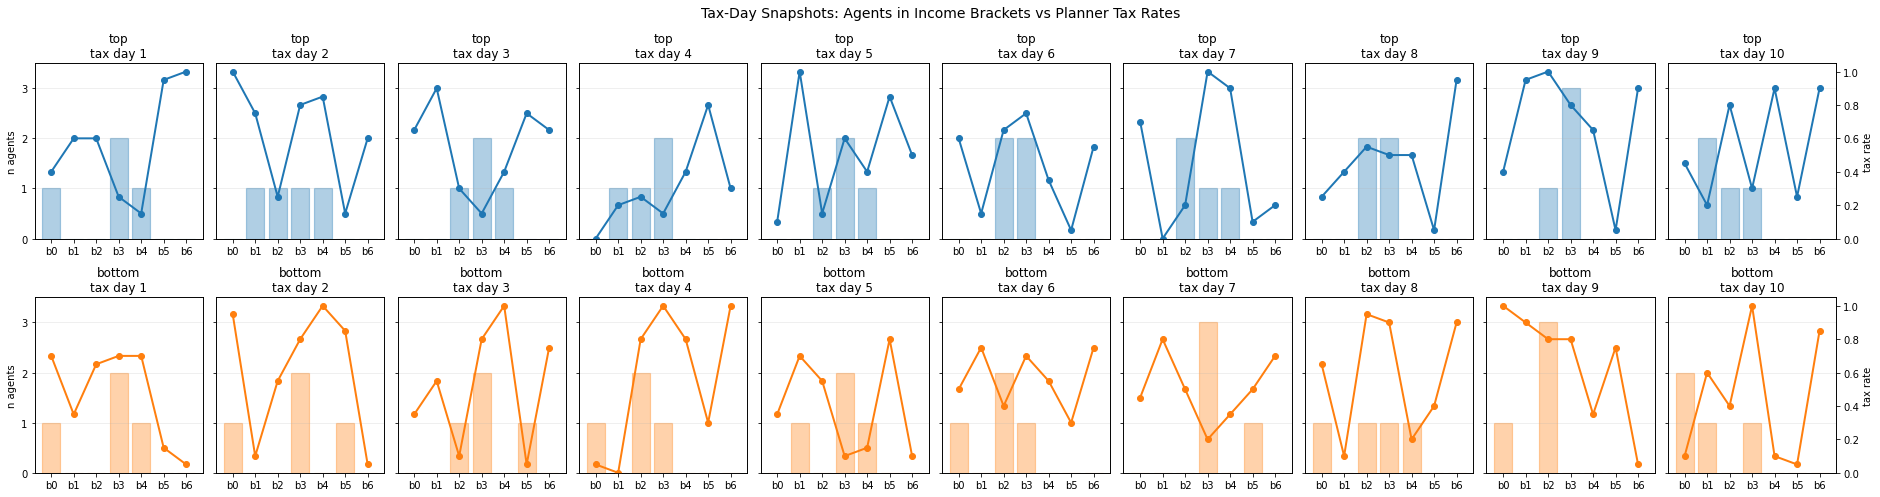

In [ ]:
log = _extract_logs_from_run(runs[0])[0]

fig_snapshots, df_income_snapshots, df_counts_snapshots = plot_tax_bracket_snapshots(
    log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    n_snapshots=10,
    top_first=True,
)


In [78]:
def plot_tax_bracket_snapshots_with_rewards_safe(
    log,
    env_obj,
    brackets,
    period=100,
    n_snapshots=10,
    top_first=True,
    reward_mode="instant",
    figsize=None,
):
    df_income, counts, labels = _income_bracket_counts(log, brackets, period=period)
    ptop_rates, pbot_rates = _tax_rate_matrices(log, env_obj, top_first=top_first)

    rewards_top = np.asarray(log.get("planner_rewards", {}).get("p_top", []), dtype=float)
    rewards_bottom = np.asarray(log.get("planner_rewards", {}).get("p_bottom", []), dtype=float)

    if reward_mode == "cumulative":
        rewards_top = np.nancumsum(rewards_top)
        rewards_bottom = np.nancumsum(rewards_bottom)
        reward_label = "cum reward"
    else:
        reward_label = "reward"

    tax_days = sorted(df_income["tax_day_number"].unique())
    if len(tax_days) <= n_snapshots:
        chosen_days = tax_days
    else:
        idx = np.linspace(0, len(tax_days) - 1, n_snapshots).round().astype(int)
        chosen_days = [tax_days[i] for i in idx]

    if figsize is None:
        figsize = (2.3 * len(chosen_days), 9.5)

    fig, axes = plt.subplots(
        6,
        len(chosen_days),
        figsize=figsize,
        sharex="col",
        gridspec_kw={"height_ratios": [2.4, 1.2, 0.8, 2.4, 1.2, 0.8]},
    )

    if len(chosen_days) == 1:
        axes = np.asarray(axes).reshape(6, 1)

    bracket_x = np.arange(len(labels))
    max_count = max(1, int(counts["n_agents"].max()))

    all_rewards = np.concatenate([
        rewards_top[np.isfinite(rewards_top)] if len(rewards_top) else np.array([]),
        rewards_bottom[np.isfinite(rewards_bottom)] if len(rewards_bottom) else np.array([]),
    ])
    if len(all_rewards):
        reward_min, reward_max = float(np.nanmin(all_rewards)), float(np.nanmax(all_rewards))
        if reward_min == reward_max:
            reward_min -= 1
            reward_max += 1
    else:
        reward_min, reward_max = -1, 1

    def day_to_idx(tax_day, matrix):
        if len(tax_days) == 1 or matrix.shape[0] == 1:
            return 0
        frac = (tax_day - tax_days[0]) / (tax_days[-1] - tax_days[0])
        return int(np.clip(round(frac * (matrix.shape[0] - 1)), 0, matrix.shape[0] - 1))

    def reward_at(decision_idx, rewards):
        if len(rewards) == 0:
            return np.nan
        if len(rewards) == 1:
            return rewards[0]
        frac = decision_idx / max(1, ptop_rates.shape[0] - 1)
        ridx = int(np.clip(round(frac * (len(rewards) - 1)), 0, len(rewards) - 1))
        return rewards[ridx]

    configs = [
        ("top", ptop_rates, rewards_top, "#1f77b4", 0, 1, 2),
        ("bottom", pbot_rates, rewards_bottom, "#ff7f0e", 3, 4, 5),
    ]

    for region, rates_matrix, rewards, color, count_row, tax_row, reward_row in configs:
        for col, tax_day in enumerate(chosen_days):
            decision_idx = day_to_idx(tax_day, rates_matrix)
            rates = rates_matrix[decision_idx]

            day_counts = (
                counts[
                    (counts["planner_region"] == region)
                    & (counts["tax_day_number"] == tax_day)
                ]
                .set_index("tax_bracket")["n_agents"]
                .reindex(labels)
                .fillna(0)
            )

            ax = axes[count_row, col]
            ax.bar(bracket_x, day_counts.values, color=color, alpha=0.45)
            ax.set_ylim(0, max_count + 0.5)
            ax.set_title(f"{region} day {tax_day}", fontsize=9)
            ax.grid(True, axis="y", alpha=0.25)
            if col == 0:
                ax.set_ylabel("n agents")
            else:
                ax.tick_params(axis="y", labelleft=False)

            ax = axes[tax_row, col]
            ax.plot(bracket_x, rates, marker="o", color=color, linewidth=1.8)
            ax.set_ylim(0, max(1.0, np.nanmax(rates_matrix) * 1.05))
            ax.grid(True, axis="y", alpha=0.25)
            if col == 0:
                ax.set_ylabel("tax rate")
            else:
                ax.tick_params(axis="y", labelleft=False)

            ax = axes[reward_row, col]
            rv = reward_at(decision_idx, rewards)
            ax.axhline(0, color="black", linewidth=0.7)
            ax.bar([0], [rv], color=color, alpha=0.75, width=0.6)
            ax.set_ylim(reward_min, reward_max)
            ax.set_xticks([])
            ax.grid(True, axis="y", alpha=0.2)
            if col == 0:
                ax.set_ylabel(reward_label)
            else:
                ax.tick_params(axis="y", labelleft=False)

            axes[5, col].set_xticks(bracket_x)
            axes[5, col].set_xticklabels([f"b{i}" for i in range(len(labels))], fontsize=8)

    fig.suptitle("Tax-Day Snapshots: Counts, Tax Rates, Planner Rewards", fontsize=14)
    fig.subplots_adjust(top=0.92, hspace=0.45, wspace=0.25)

    return fig, df_income, counts


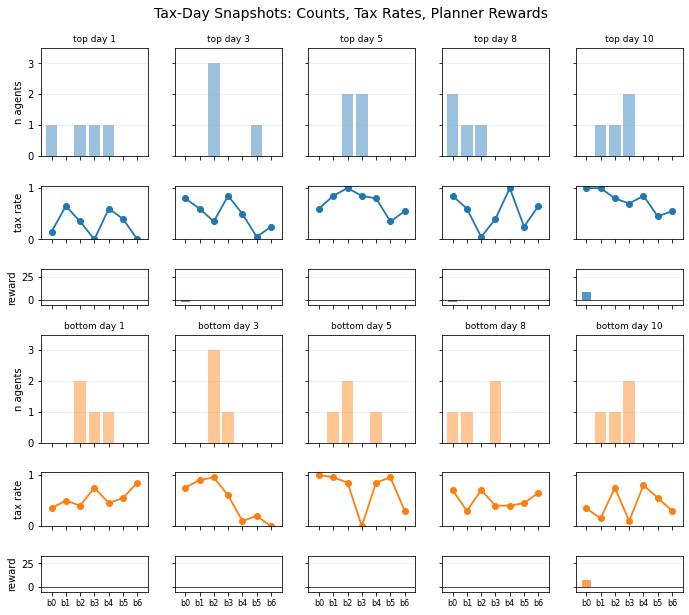

In [79]:
fig_rewards, df_income_rewards, df_counts_rewards = plot_tax_bracket_snapshots_with_rewards_safe(
    log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    n_snapshots=5,
    top_first=True,
    reward_mode="instant",
)


In [80]:
def _equality_from_values(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) <= 1:
        return 1.0

    values = np.maximum(values, 0.0)
    mean = np.mean(values)

    if mean <= 0:
        return 1.0

    diffs = np.abs(values[:, None] - values[None, :])
    gini = np.mean(diffs) / (2.0 * mean)
    return float(1.0 - gini)


def _period_swf_table(log, period=100):
    states = log["states"]
    aids = _numeric_agent_ids(log)
    waterline = _infer_waterline(log)

    planner_rewards = log.get("planner_rewards", {})
    rewards_top = np.asarray(planner_rewards.get("p_top", []), dtype=float)
    rewards_bottom = np.asarray(planner_rewards.get("p_bottom", []), dtype=float)

    tax_days = list(range(period - 1, len(states), period))
    rows = []

    for tax_day_number, t in enumerate(tax_days, start=1):
        t_start = 0 if tax_day_number == 1 else tax_days[tax_day_number - 2] + 1
        t_end = t + 1

        for region, planner_id, reward_arr in [
            ("top", "p_top", rewards_top),
            ("bottom", "p_bottom", rewards_bottom),
        ]:
            assigned = [
                aid for aid in aids
                if _planner_region_from_initial_state(log, aid, waterline=waterline) == region
            ]

            state = states[t]
            coins = np.array([_coin(state[str(aid)]) for aid in assigned], dtype=float)

            production = float(np.sum(coins)) if len(coins) else np.nan
            equality = _equality_from_values(coins) if len(coins) else np.nan
            swf_proxy = production * equality if np.isfinite(production) and np.isfinite(equality) else np.nan

            reward_slice = reward_arr[t_start:min(t_end, len(reward_arr))]
            reward_slice = reward_slice[np.isfinite(reward_slice)]

            rows.append({
                "tax_day_number": tax_day_number,
                "planner_region": region,
                "planner_id": planner_id,
                "production": production,
                "equality": equality,
                "swf_proxy": swf_proxy,
                "planner_reward_sum": float(np.sum(reward_slice)) if len(reward_slice) else np.nan,
                "planner_reward_mean": float(np.mean(reward_slice)) if len(reward_slice) else np.nan,
                "n_agents": len(assigned),
            })

    return pd.DataFrame(rows)



def plot_tax_bracket_snapshots_compact(
    log,
    env_obj,
    brackets,
    period=100,
    n_snapshots=10,
    top_first=True,
    figsize=None,
):
    df_income, counts, labels = _income_bracket_counts(log, brackets, period=period)
    df_swf = _period_swf_table(log, period=period)

    ptop_rates, pbot_rates = _tax_rate_matrices(log, env_obj, top_first=top_first)

    planner_rewards = log.get("planner_rewards", {})
    rewards_top = np.asarray(planner_rewards.get("p_top", []), dtype=float)
    rewards_bottom = np.asarray(planner_rewards.get("p_bottom", []), dtype=float)

    tax_days = sorted(df_income["tax_day_number"].unique())

    if len(tax_days) <= n_snapshots:
        chosen_days = tax_days
    else:
        idx = np.linspace(0, len(tax_days) - 1, n_snapshots).round().astype(int)
        chosen_days = [tax_days[i] for i in idx]

    if figsize is None:
        figsize = (2.8 * len(chosen_days), 6.2)

    fig, axes = plt.subplots(
        2,
        len(chosen_days),
        figsize=figsize,
        sharey=True,
        constrained_layout=True,
    )

    if len(chosen_days) == 1:
        axes = np.asarray(axes).reshape(2, 1)

    bracket_x = np.arange(len(labels))
    max_count = max(1, int(counts["n_agents"].max()))

    configs = [
        ("top", "p_top", ptop_rates, rewards_top, "#1f77b4", 0),
        ("bottom", "p_bottom", pbot_rates, rewards_bottom, "#ff7f0e", 1),
    ]

    def tax_day_to_decision_idx(tax_day, rate_matrix):
        if rate_matrix.shape[0] == len(tax_days):
            return min(tax_day - 1, rate_matrix.shape[0] - 1)

        if len(tax_days) == 1 or rate_matrix.shape[0] == 1:
            return 0

        frac = (tax_day - tax_days[0]) / (tax_days[-1] - tax_days[0])
        return int(np.clip(round(frac * (rate_matrix.shape[0] - 1)), 0, rate_matrix.shape[0] - 1))

    def reward_at_decision(decision_idx, reward_arr):
        if len(reward_arr) == 0:
            return np.nan
        if len(reward_arr) == ptop_rates.shape[0] or len(reward_arr) == pbot_rates.shape[0]:
            return reward_arr[min(decision_idx, len(reward_arr) - 1)]
        if len(reward_arr) == len(tax_days):
            return reward_arr[min(decision_idx, len(reward_arr) - 1)]
        if len(reward_arr) == 1:
            return reward_arr[0]

        frac = decision_idx / max(1, ptop_rates.shape[0] - 1)
        ridx = int(np.clip(round(frac * (len(reward_arr) - 1)), 0, len(reward_arr) - 1))
        return reward_arr[ridx]

    for region, planner_id, rate_matrix, reward_arr, color, row in configs:
        tax_ymax = max(1.0, float(np.nanmax(rate_matrix)) * 1.05)

        for col, tax_day in enumerate(chosen_days):
            ax = axes[row, col]

            day_counts = (
                counts[
                    (counts["planner_region"] == region)
                    & (counts["tax_day_number"] == tax_day)
                ]
                .set_index("tax_bracket")["n_agents"]
                .reindex(labels)
                .fillna(0)
            )

            decision_idx = tax_day_to_decision_idx(tax_day, rate_matrix)
            rates = rate_matrix[decision_idx]

            scaled_rates = rates / tax_ymax * max_count

            ax.bar(
                bracket_x,
                day_counts.values,
                color=color,
                alpha=0.35,
                edgecolor=color,
                linewidth=1.1,
            )

            ax.plot(
                bracket_x,
                scaled_rates,
                color=color,
                marker="o",
                linewidth=2.2,
            )

            swf_row = df_swf[
                (df_swf["tax_day_number"] == tax_day)
                & (df_swf["planner_region"] == region)
            ]

            if len(swf_row):
                sr = swf_row.iloc[0]
                production = sr["production"]
                equality = sr["equality"]
            else:
                production = np.nan
                equality = np.nan

            planner_reward = sr["planner_reward_sum"]


            txt = (
                f"{planner_id} R sum: {planner_reward:.3g}\n"
                f"prod: {production:.3g}\n"
                f"eq: {equality:.3f}"
            )


            ax.text(
                0.03,
                0.95,
                txt,
                transform=ax.transAxes,
                va="top",
                ha="left",
                fontsize=8,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75),
            )

            ax.set_ylim(0, max_count + 0.5)
            ax.set_yticks(range(0, max_count + 1))

            if col == 0:
                ax.set_ylabel("n agents")
            else:
                ax.tick_params(axis="y", labelleft=False)

            if col == len(chosen_days) - 1:
                axr = ax.secondary_yaxis(
                    "right",
                    functions=(
                        lambda y: y / max_count * tax_ymax,
                        lambda y: y / tax_ymax * max_count,
                    ),
                )
                axr.set_ylabel("tax rate")

            ax.set_title(f"{planner_id}\ntax day {tax_day}", fontsize=10)
            ax.set_xticks(bracket_x)
            ax.set_xticklabels([f"b{i}" for i in range(len(labels))], fontsize=8)
            ax.grid(True, axis="y", alpha=0.25)

    fig.suptitle(
        "Tax-Day Snapshots: Bracket Counts, Tax Rates, Planner Reward, Production, Equality",
        fontsize=14,
    )

    return fig, df_income, counts, df_swf


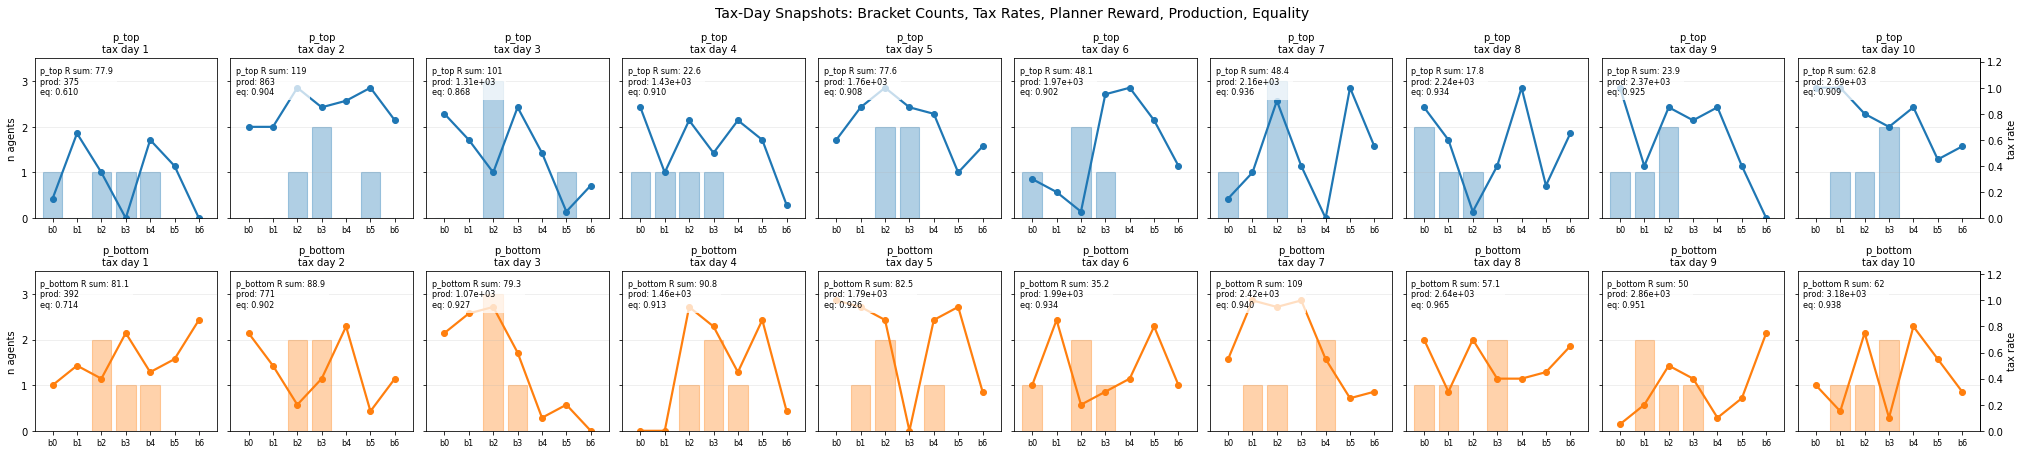

In [81]:
fig_snap, df_income_snap, df_counts_snap, df_swf_snap = plot_tax_bracket_snapshots_compact(
    log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    n_snapshots=10,
    top_first=True,
)


# debug and DF

In [82]:
for i, r in enumerate(runs):
    print(i, len(r["dense_log"]))

0 11
1 11
2 11


In [83]:
import numpy as np

values = []
for r in runs:
    log = r["dense_log"]
    values.append(log["planner_actions"]["p_top"].mean())

print(np.std(values))

0.2636736799982309


In [84]:
for i, r in enumerate(runs):
    print("run", i)
    print(r["dense_log"].keys())
    print(type(r["dense_log"]["states"]), len(r["dense_log"]["states"]))
    print(r["dense_log"]["planner_actions"]["p_top"].shape)

run 0
dict_keys(['world', 'states', 'actions', 'rewards', 'Build', 'Trade', 'Gather', 'PeriodicTax', 'CrossWaterTravel', 'planner_actions', 'planner_rewards'])
<class 'list'> 1001
(10, 14)
run 1
dict_keys(['world', 'states', 'actions', 'rewards', 'Build', 'Trade', 'Gather', 'PeriodicTax', 'CrossWaterTravel', 'planner_actions', 'planner_rewards'])
<class 'list'> 1001
(10, 14)
run 2
dict_keys(['world', 'states', 'actions', 'rewards', 'Build', 'Trade', 'Gather', 'PeriodicTax', 'CrossWaterTravel', 'planner_actions', 'planner_rewards'])
<class 'list'> 1001
(10, 14)


In [85]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\tutorials\results\travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028\training_metrics.csv")
cols = [c for c in df.columns if "reward" in c.lower() or "p_top" in c or "p_bottom" in c]
df[cols].tail(20)

,episode_reward_mean,episode_reward_min,episode_reward_max,policy_reward_mean/p_top,policy_reward_mean/p_bottom,policy_reward_mean/a
3980,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3981,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3982,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3983,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3984,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3985,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3986,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3987,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3988,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3989,2580.148370,1890.445560,3066.794823,657.497871,664.069651,157.322606


In [86]:
def inspect_planner_rewards(log):
    if "planner_rewards" not in log:
        print("No planner_rewards in dense log.")
        return

    for pid in ["p_top", "p_bottom"]:
        arr = np.array(log["planner_rewards"].get(pid, []), dtype=float)
        print(pid)
        print("  len:", len(arr))
        print("  finite:", np.isfinite(arr).all() if len(arr) else None)
        print("  min/max/mean/sum:", 
              np.nanmin(arr) if len(arr) else None,
              np.nanmax(arr) if len(arr) else None,
              np.nanmean(arr) if len(arr) else None,
              np.nansum(arr) if len(arr) else None)
        print("  nonzero count:", np.sum(np.abs(arr) > 1e-9) if len(arr) else 0)

In [87]:
inspect_planner_rewards(dense_logs[0])

p_top
  len: 1000
  finite: True
  min/max/mean/sum: -4.1666666666666 32.92802083333221 0.599504791666667 599.5047916666671
  nonzero count: 337
p_bottom
  len: 1000
  finite: True
  min/max/mean/sum: -5.362500000000182 20.397708333332673 0.7353698958333336 735.3698958333335
  nonzero count: 373


In [88]:
def planner_rewards_at_tax_days(log, period=100):
    rows = []
    for pid in ["p_top", "p_bottom"]:
        arr = np.array(log.get("planner_rewards", {}).get(pid, []), dtype=float)
        for t, val in enumerate(arr):
            rows.append({
                "planner": pid,
                "t": t,
                "reward": val,
                "is_tax_day": (t % period == period - 1) or (t % period == 0),
            })
    return pd.DataFrame(rows)

dfr = planner_rewards_at_tax_days(dense_logs[0], period=100)
dfr.groupby(["planner", "is_tax_day"])["reward"].agg(["count", "mean", "sum", "min", "max"])

count      mean         sum       min        max
planner  is_tax_day                                                  
p_bottom False         980  0.657234  644.089167 -3.000000  17.500000
         True           20  4.564036   91.280729 -5.362500  20.397708
p_top    False         980  0.488607  478.834375 -4.166667  17.333333
         True           20  6.033521  120.670417 -2.500000  32.928021

In [89]:
from pathlib import Path
import pickle

run_dir = Path(run_dirs[0])  

with open(run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

df_income, df_tax_counts = plotting.tax_day_income_report(
    dense_logs[0],
    period=100,
)

df_income.head(16)

,tax_day_number,timestep,agent,region,state_region,location_region,split_row,coin_start,coin_end,income,tax_bracket
0,1,99,0,top,None,top,25,0.0,177.000000,177.000000,"[160.725, 204.100)"
1,1,99,1,top,None,top,25,0.0,58.000000,58.000000,"[39.475, 84.200)"
2,1,99,2,top,None,top,25,0.0,133.000000,133.000000,"[84.200, 160.725)"
3,1,99,3,top,None,bottom,25,0.0,7.000000,7.000000,"[0.000, 9.700)"
4,1,99,4,bottom,None,top,25,0.0,184.000000,184.000000,"[160.725, 204.100)"
5,1,99,5,bottom,None,bottom,25,0.0,68.000000,68.000000,"[39.475, 84.200)"
6,1,99,6,bottom,None,top,25,0.0,96.000000,96.000000,"[84.200, 160.725)"
7,1,99,7,bottom,None,top,25,0.0,44.000000,44.000000,"[39.475, 84.200)"
8,2,199,0,top,None,top,25,177.0,277.053437,100.053437,"[84.200, 160.725)"
9,2,199,1,top,None,top,25,58.0,169.357188,111.357188,"[84.200, 160.725)"


In [90]:
df_tax_counts

,tax_day_number,region,tax_bracket,n_agents
0,1,bottom,"[160.725, 204.100)",1
1,1,bottom,"[39.475, 84.200)",2
2,1,bottom,"[84.200, 160.725)",1
3,1,top,"[0.000, 9.700)",1
4,1,top,"[160.725, 204.100)",1
5,1,top,"[39.475, 84.200)",1
6,1,top,"[84.200, 160.725)",1
7,2,bottom,"[39.475, 84.200)",2
8,2,bottom,"[84.200, 160.725)",2
9,2,top,"[204.100, 510.300)",1


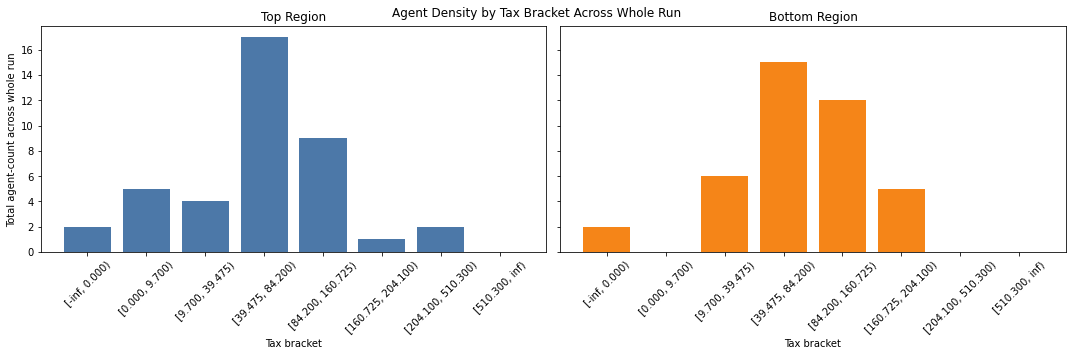

In [148]:
import matplotlib.pyplot as plt
import pandas as pd

df = df_tax_counts.copy()
df["n_agents"] = pd.to_numeric(df["n_agents"], errors="coerce").fillna(0)

bracket_order = [
    "[-inf, 0.000)",
    "[0.000, 9.700)",
    "[9.700, 39.475)",
    "[39.475, 84.200)",
    "[84.200, 160.725)",
    "[160.725, 204.100)",
    "[204.100, 510.300)",
    "[510.300, inf)",
]

counts = (
    df.groupby(["region", "tax_bracket"])["n_agents"]
      .sum()
      .unstack(fill_value=0)
      .reindex(columns=bracket_order, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

colors = {"top": "#4C78A8", "bottom": "#F58518"}

for ax, region in zip(axes, ["top", "bottom"]):
    y = counts.loc[region] if region in counts.index else pd.Series(0, index=bracket_order)

    ax.bar(y.index, y.values, color=colors[region])
    ax.set_title(f"{region.capitalize()} Region")
    ax.set_xlabel("Tax bracket")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Total agent-count across whole run")

plt.suptitle("Agent Density by Tax Bracket Across Whole Run")
plt.tight_layout()
plt.show()


In [91]:
all_income = []
all_counts = []

for rollout_id, log in dense_logs.items():
    df_income, df_counts = plotting.tax_day_income_report(log, period=100)

    df_income["rollout_id"] = rollout_id
    df_counts["rollout_id"] = rollout_id

    all_income.append(df_income)
    all_counts.append(df_counts)

df_income_all = pd.concat(all_income, ignore_index=True)
df_tax_counts_all = pd.concat(all_counts, ignore_index=True)

In [92]:
df_income_all.head(20)
df_tax_counts_all

,tax_day_number,region,tax_bracket,n_agents,rollout_id
0,1,bottom,"[160.725, 204.100)",1,0
1,1,bottom,"[39.475, 84.200)",2,0
2,1,bottom,"[84.200, 160.725)",1,0
3,1,top,"[0.000, 9.700)",1,0
4,1,top,"[160.725, 204.100)",1,0
...,...,...,...,...,...
1033,10,bottom,"[39.475, 84.200)",1,19
1034,10,bottom,"[9.700, 39.475)",1,19
1035,10,top,"[0.000, 9.700)",2,19
1036,10,top,"[39.475, 84.200)",1,19


In [93]:
import importlib
importlib.reload(plotting)


<module 'utils.plotting' from 'c:\\Users\\adria\\coding\\katja\\DRL-in-international-economy-ai-economist-\\tutorials\\utils\\plotting.py'>

In [107]:
#result_dir = r"results/travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028"
#result_dir = r"results/travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade_20260501_163728"
result_dir = r"results/travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__with_travel_20260502_225247"


In [108]:
dense_log, dense_logs = plotting.get_dense_log_from_result_folder(result_dir, episode_key=0)

_______________:_ Agent  0 _____|_ Agent  4 _____|_ Agent  1 _____|_ Agent  5 _____|_ Agent  2 _____|_ Agent  6 _____|_ Agent  3 _____|_ Agent  7 ____
Cost (Wood)    :   4.67 (n= 27) |   4.76 (n= 17) |   4.66 (n= 71) |   5.14 (n= 43) |   6.43 (n= 93) |   5.12 (n= 66) |   5.45 (n=110) |   5.04 (n=248)
Cost (Stone)   :   6.23 (n= 60) |   6.56 (n= 55) |   6.21 (n= 56) |   7.46 (n= 57) |   6.25 (n=114) |   6.71 (n= 95) |   7.18 (n= 79) |   7.81 (n=207)

Income (Wood)  :   5.11 (n=113) |   5.07 (n=152) |   5.10 (n= 50) |   5.46 (n= 28) |   5.44 (n= 94) |   5.54 (n= 89) |   5.56 (n= 64) |   5.06 (n= 85)
Income (Stone) :   6.87 (n=101) |   6.68 (n= 76) |   7.17 (n=156) |   7.53 (n=131) |   6.16 (n= 51) |   6.58 (n= 40) |   7.66 (n= 64) |   6.42 (n=104)
Income (Build) :  11.00 (n= 26) |  11.00 (n= 16) |  13.00 (n= 18) |  13.00 (n= 13) |  16.00 (n= 65) |  16.00 (n= 56) |  22.00 (n= 41) |  22.00 (n=159)


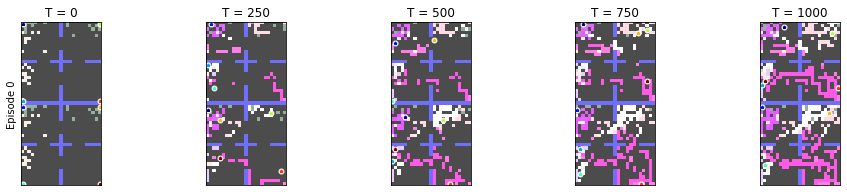

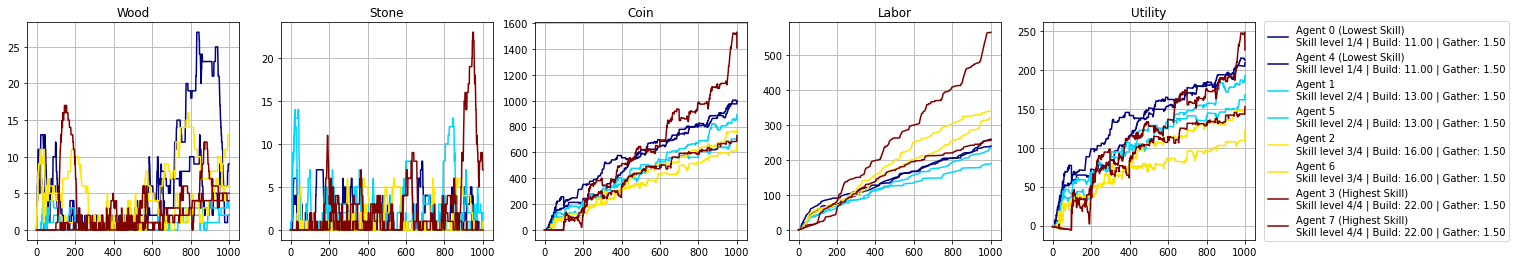

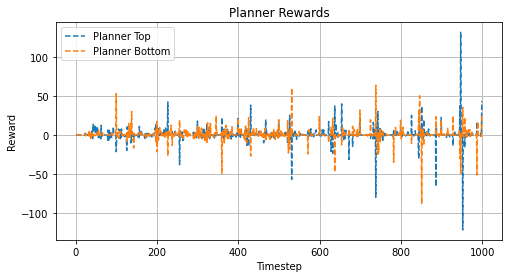

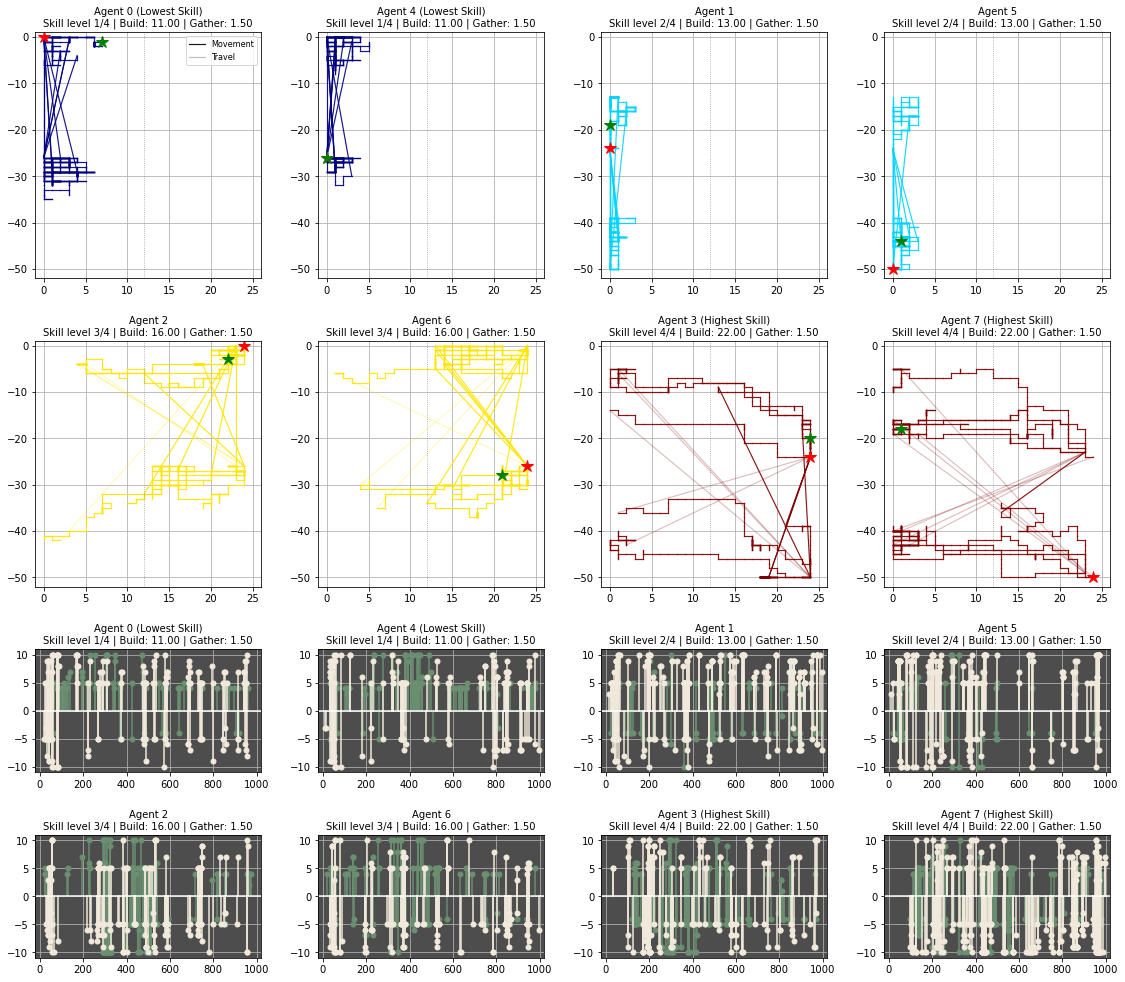

In [109]:
breakdown, dense_log, dense_logs = plotting.breakdown_all_agents_from_result_folder(
    result_dir,
    episode_key=1,
    #remap_key="build_payment"
)

# Figuring out agent movement

In [110]:
df_agents, df_summary = plotting.diagnose_agent_activity_df(runs[0]["dense_log"])
df_agents

,agent,movement,coin,wood,stone,labor
0,0,555.0,816.139375,0.0,2.0,251.71
1,1,427.0,645.649375,0.0,10.0,213.10
2,2,298.0,539.259375,0.0,1.0,159.04
3,3,365.0,687.951875,0.0,16.0,197.92
4,4,688.0,841.247813,9.0,3.0,269.60
5,5,422.0,672.485313,1.0,0.0,168.33
6,6,787.0,887.509063,0.0,1.0,357.28
7,7,573.0,776.757812,1.0,0.0,254.01


In [111]:
all_summaries = []

for run in runs:
    _, df_sum = plotting.diagnose_agent_activity_df(run["dense_log"])
    df_sum["run"] = run["name"]
    all_summaries.append(df_sum)

df_all = pd.concat(all_summaries, ignore_index=True)
df_all

,steps,n_builds,n_trades,n_gathers,avg_movement,total_coin,total_wood,total_stone,run
0,1000,365,755,514,514.375,5867.0,11.0,33.0,travel-off__regionaltrade-on__layout-stacked_5...
1,1000,422,1303,602,702.625,7312.0,28.0,37.0,travel-off__regionaltrade-off__layout-stacked_...
2,1000,395,1675,567,911.000,7266.0,33.0,15.0,travel-on__regionaltrade-off__layout-stacked_5...


In [112]:
usd_scaling = 1000
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling

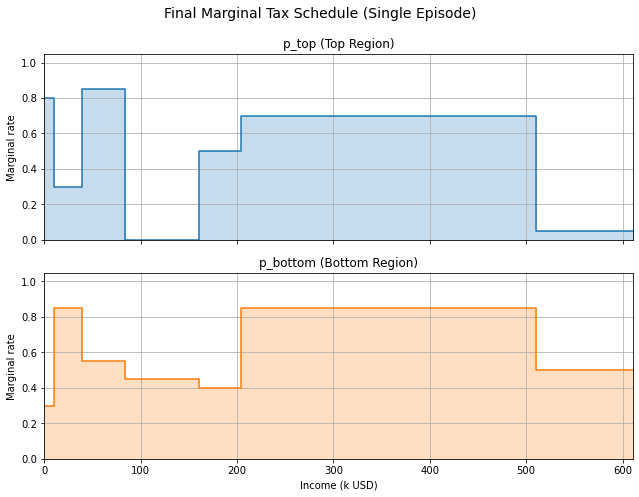

In [113]:
single_dense_log = {0: dense_logs[0]}  # keep only episode 0

fig_single = plotting.plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=single_dense_log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Final Marginal Tax Schedule (Single Episode)",
    errorbar=None,  
    last_bin_width=100,
)

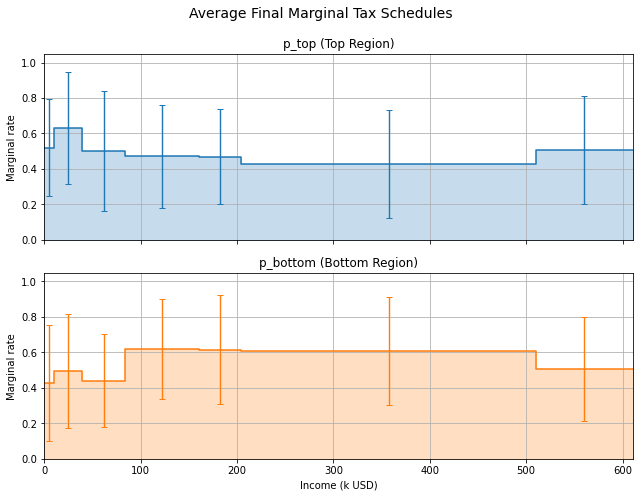

In [114]:
fig_avg_final = plotting.plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules",
    errorbar="std",
    last_bin_width=100, 
)

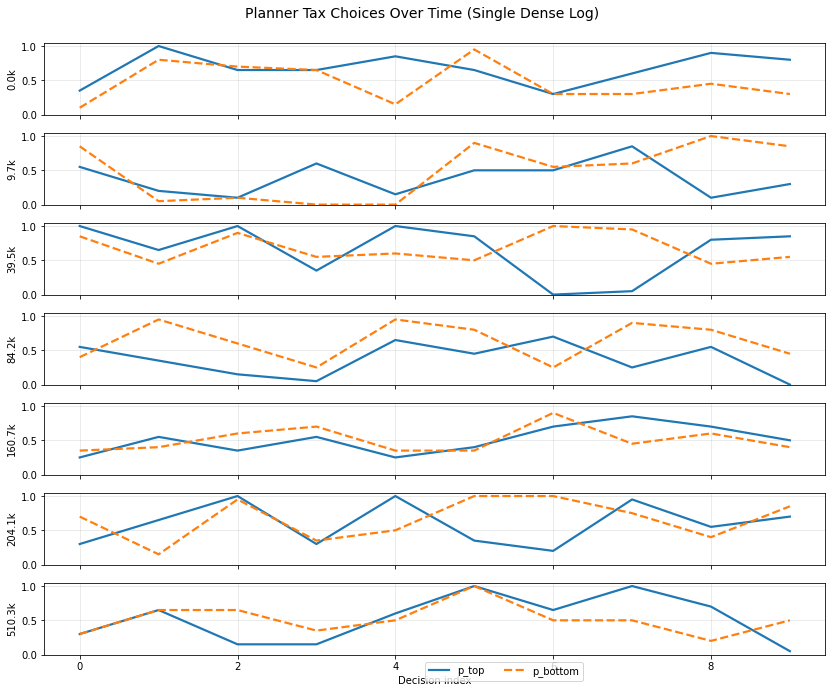

In [115]:
fig_single = plotting.plot_planner_tax_lines(
    dense_logs={0: dense_logs[0]},
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    mode="single",
    errorbar=None,
    title="Planner Tax Choices Over Time (Single Dense Log)"
)

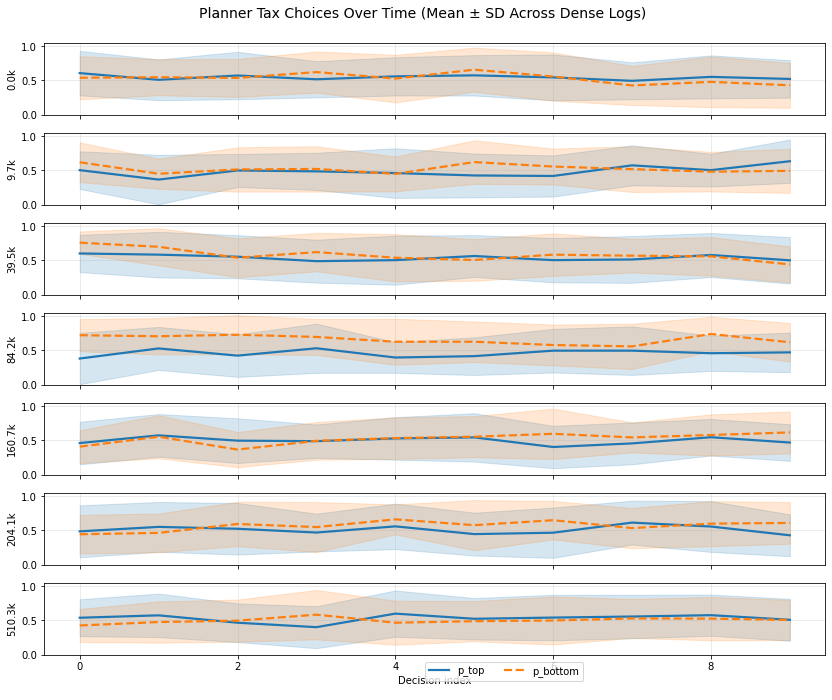

In [116]:
fig_avg = plotting.plot_planner_tax_lines(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    mode="average",
    errorbar="std",
    title="Planner Tax Choices Over Time (Mean ± SD Across Dense Logs)"
)

In [117]:
df_regions = plotting.agent_region_time_table(
    runs[0]["dense_log"],
    split_row=25,
    use_region_field=False,
    normalize=True,
)
df_regions

,timesteps_top,timesteps_bottom,total_timesteps,final_region,share_top,share_bottom
agent,,,,,,
0,1001,0,1001,top,1.0,0.0
1,1001,0,1001,top,1.0,0.0
2,1001,0,1001,top,1.0,0.0
3,1001,0,1001,top,1.0,0.0
4,0,1001,1001,bottom,0.0,1.0
5,0,1001,1001,bottom,0.0,1.0
6,0,1001,1001,bottom,0.0,1.0
7,0,1001,1001,bottom,0.0,1.0


In [118]:
df_spells = plotting.agent_region_spell_table(
    runs[0]["dense_log"],
    split_row=25,
    use_region_field=False,
)
df_spells

,timesteps_top,timesteps_bottom,n_region_switches,n_top_spells,n_bottom_spells,avg_top_spell,avg_bottom_spell,avg_spell_overall,final_region
agent,,,,,,,,,
0,1001,0,0,1,0,1001.0,NaN,1001.0,top
1,1001,0,0,1,0,1001.0,NaN,1001.0,top
2,1001,0,0,1,0,1001.0,NaN,1001.0,top
3,1001,0,0,1,0,1001.0,NaN,1001.0,top
4,0,1001,0,0,1,NaN,1001.0,1001.0,bottom
5,0,1001,0,0,1,NaN,1001.0,1001.0,bottom
6,0,1001,0,0,1,NaN,1001.0,1001.0,bottom
7,0,1001,0,0,1,NaN,1001.0,1001.0,bottom


# single agent single move

In [132]:
from pathlib import Path
import pickle
import ray

BASE_RESULTS_DIR = Path("tutorials/results") if Path("tutorials/results").exists() else Path("results")

result_run_dir = BASE_RESULTS_DIR / "travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028"

with open(result_run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

ray.shutdown()
ray.init(ignore_reinit_error=True, log_to_driver=False, logging_level="ERROR")


{'node_ip_address': '192.168.1.108',
 'raylet_ip_address': '192.168.1.108',
 'redis_address': '192.168.1.108:6379',
 'object_store_address': 'tcp://127.0.0.1:64945',
 'raylet_socket_name': 'tcp://127.0.0.1:60150',
 'webui_url': 'localhost:8265',
 'session_dir': 'C:\\Users\\adria\\AppData\\Local\\Temp\\ray\\session_2026-05-04_11-07-02_275476_2572'}

In [133]:
import os
import glob
import json

def find_local_phase3b_checkpoint(run_dir):
    # Try common saved checkpoint locations inside your run folder
    candidates = glob.glob(os.path.join(run_dir, "**", "checkpoint-*"), recursive=True)

    # keep only actual checkpoint files, not metadata
    candidates = [
        p for p in candidates
        if os.path.isfile(p) and not p.endswith(".tune_metadata")
    ]

    if len(candidates) == 0:
        raise FileNotFoundError(f"No checkpoint-* file found inside {run_dir}")

    # choose latest checkpoint number
    def ckpt_num(path):
        base = os.path.basename(path)
        return int(base.split("-")[-1])

    return sorted(candidates, key=ckpt_num)[-1]

In [134]:
from pathlib import Path

def load_trainer_from_run(run_dir, settings):
    import json

    run_dir = Path(run_dir)  # <-- important fix

    with open(run_dir / "config.json", "r") as f:
        cfg = json.load(f)

    with open(run_dir / "checkpoints.json", "r") as f:
        ckpts = json.load(f)

    env_config = cfg["env_config_dict_phase3b"]

    env_obj = exp.create_env(env_config)

    trainer = exp.create_trainer(
        settings=settings,
        env_config_dict=env_config,
        env_obj=env_obj,
        policies_to_train=["a", "p_top", "p_bottom"],
    )
 
    local_ckpt = find_local_phase3b_checkpoint(run_dir)
    print("Restoring from:", local_ckpt)
    trainer.restore(local_ckpt)

    return trainer, env_obj

In [135]:
from utils import single

In [137]:
import os
os.environ["RAY_DISABLE_MEMORY_MONITOR"] = "1"

from pathlib import Path
import json
import pickle
from dataclasses import fields

import ray
import simulation as exp
from utils import single

ray.shutdown()
ray.init(
    ignore_reinit_error=True,
    log_to_driver=False,
    logging_level="ERROR",
)

BASE_RESULTS_DIR = Path("tutorials/results") if Path("tutorials/results").exists() else Path("results")

result_run_dir = BASE_RESULTS_DIR / "travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028"

with open(result_run_dir / "config.json", "r") as f:
    cfg = json.load(f)

with open(result_run_dir / "checkpoints.json", "r") as f:
    ckpts = json.load(f)

with open(result_run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

settings_from_result = exp.ExperimentSettings(**{
    f.name: cfg[f.name]
    for f in fields(exp.ExperimentSettings)
    if f.name in cfg
})

env_config = cfg["env_config_dict_phase3b"]
env_obj_phase3b = exp.create_env(env_config)

checkpoint_path = Path(ckpts["phase3b"]).resolve()
print("Checkpoint:", checkpoint_path)
print("Exists:", checkpoint_path.exists())

trainer_phase3b = exp.create_trainer(
    settings=settings_from_result,
    env_config_dict=env_config,
    env_obj=env_obj_phase3b,
    policies_to_train=["a", "p_top", "p_bottom"],
)

trainer_phase3b.restore(str(checkpoint_path))

2026-05-04 11:15:06,655	ERROR syncer.py:46 -- Log sync requires rsync to be installed.


Checkpoint: C:\home\adbo\ray_results\PPO_RLlibEnvWrapper_2026-05-01_02-55-29i8e7b8o_\checkpoint_1500\checkpoint-1500
Exists: False


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\home\\adbo\\ray_results\\PPO_RLlibEnvWrapper_2026-05-01_02-55-29i8e7b8o_\\checkpoint_1500\\checkpoint-1500.tune_metadata'

In [ ]:
paired_baseline_log, paired_forced_log = single.generate_paired_baseline_forced_rollouts(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)


In [ ]:
forced_log = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

In [ ]:
df_move_summary = single.forced_move_agent_summary(forced_log, window_before=100, window_after=100)
df_move_summary

,period,agent,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,trade_cashflow
0,before_move,0,100,199,75.000000,31.44,55.401542,5,55.0,0,2,0,2,20.0
1,after_move,0,201,300,38.011875,46.40,64.081359,10,110.0,13,18,12,1,-45.0


In [ ]:
df_move_events = single.forced_move_event_table(forced_log, window=80)
df_move_events.head(20)
df_move_events.tail(20)

,t,relative_t,region,coin,wood,stone,labor,utility,built,bought_wood,sold_wood,bought_stone,sold_stone
141,261,61,NaN,234.61,4.0,4.0,98.03,64.946257,0,0,0,0,0
142,262,62,NaN,234.61,4.0,4.0,98.03,64.946257,0,0,0,0,0
143,263,63,NaN,234.61,4.0,4.0,98.03,64.946257,0,0,0,0,0
144,264,64,NaN,234.61,4.0,4.0,98.03,64.902157,0,0,0,0,0
145,265,65,NaN,234.61,4.0,4.0,98.24,64.858057,0,0,0,0,0
146,266,66,NaN,234.61,4.0,4.0,98.45,64.858057,0,0,0,0,0
147,267,67,NaN,234.61,4.0,4.0,98.45,64.813957,0,0,0,0,0
148,268,68,NaN,234.61,4.0,4.0,98.66,64.769857,0,0,0,0,0
149,269,69,NaN,234.61,4.0,4.0,98.87,64.725757,0,0,0,0,0
150,270,70,NaN,234.61,4.0,4.0,99.08,64.637557,0,0,0,0,0


In [ ]:
forced_log_200 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

forced_log_400 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=400,
    forced_target_region="bottom",
    explore=False,
)

forced_log_600 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=600,
    forced_target_region="bottom",
    explore=False,
)

C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\ai_economist\foundation\scenarios\utils\social_metrics.py:39: RuntimeWarning: invalid value encountered in double_scalars
  gini = unscaled_gini / ((n_agents - 1) / n_agents)


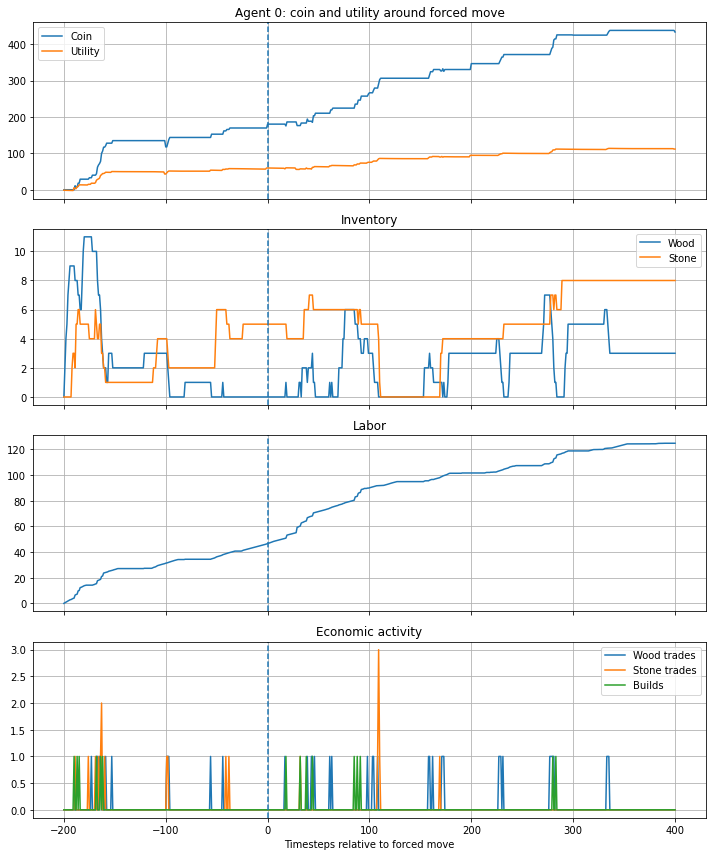

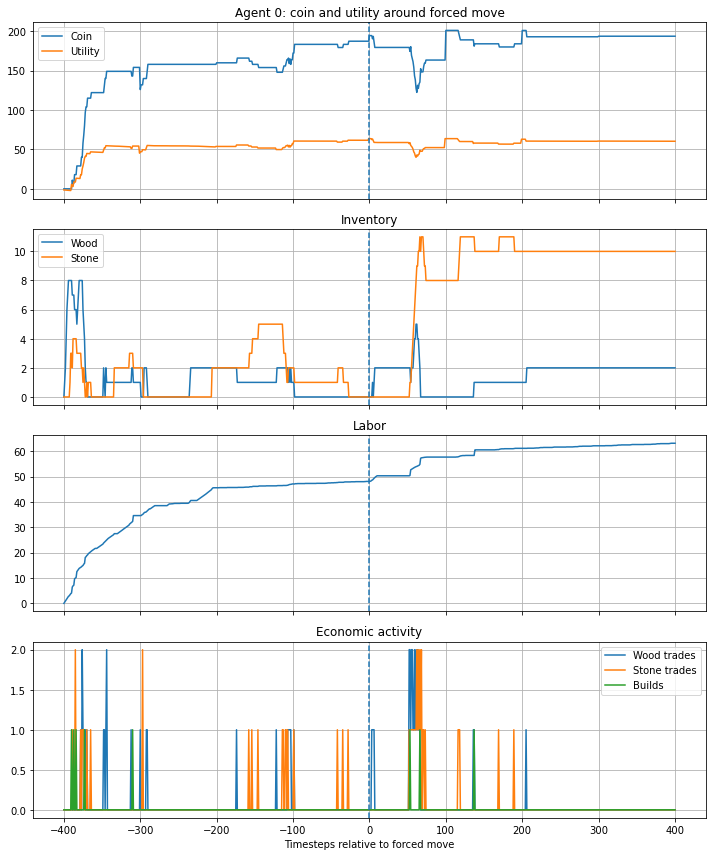

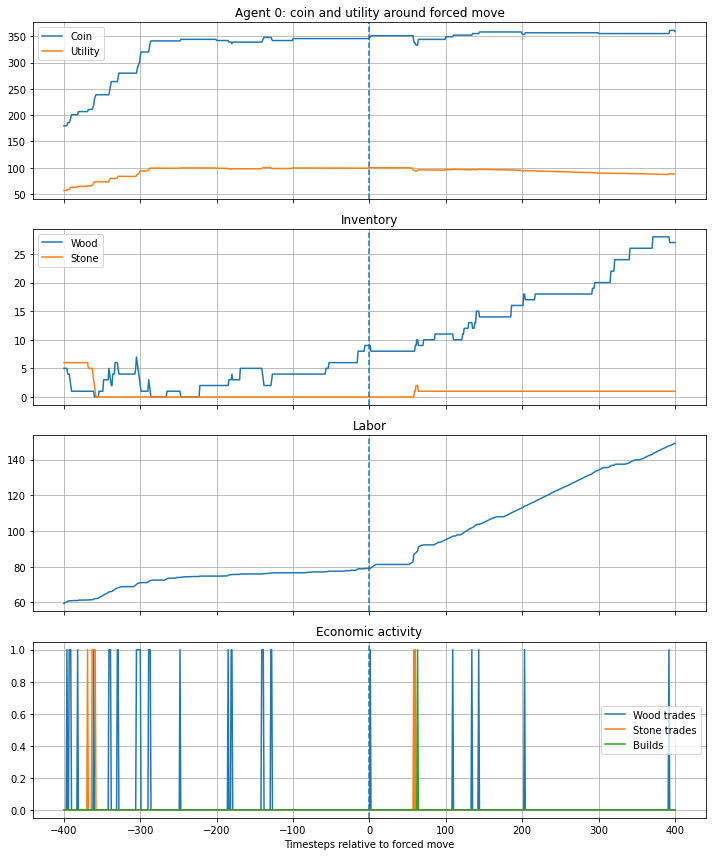

In [ ]:
fig = single.plot_forced_move_timeseries(forced_log_200, window=400)
fig = single.plot_forced_move_timeseries(forced_log_400, window=400)
fig = single.plot_forced_move_timeseries(forced_log_600, window=400)

In [ ]:
df_system = single.forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_system

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1,100,199,75.000000,31.44,55.401542,5,55.0,4,20.0,0,2,0,2,NaN,NaN
1,moved_agent,after_move,1,201,300,38.011875,46.40,64.081359,10,110.0,44,-45.0,13,18,12,1,NaN,NaN
2,other_agents,before_move,7,100,199,282.000000,116.53,44.098571,14,302.0,54,-20.0,15,13,14,12,NaN,NaN
3,other_agents,after_move,7,201,300,325.988125,134.52,54.203092,20,254.0,66,45.0,23,18,7,18,NaN,NaN


In [ ]:
# use the same moved agent and timestep as in the forced-move run
moved_agent = forced_log["forced_move"]["agent"]
reference_timestep = forced_log["forced_move"]["timestep"]

df_forced = single.forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_baseline = single.baseline_system_summary_table(
    dense_logs,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=100,
    window_after=100,
)

df_baseline

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1.0,100,199,31.000000,24.72,53.970412,1.0,11.0,10.0,20.0,2.0,5.0,1.0,2.0,NaN,NaN
1,moved_agent,after_move,1.0,201,300,101.031369,32.18,66.318329,3.0,33.0,28.0,77.0,0.0,15.0,6.0,7.0,NaN,NaN
2,other_agents,before_move,7.0,100,199,384.000000,186.01,47.046650,25.0,444.0,138.0,-20.0,27.0,24.0,44.0,43.0,NaN,NaN
3,other_agents,after_move,7.0,201,300,574.968631,207.31,61.543158,35.0,665.0,172.0,-77.0,33.0,18.0,61.0,60.0,NaN,NaN
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.604488,60.448817
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.879647,87.964687
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.350225,35.022500
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.411128,-141.112813


In [ ]:
df_forced_cmp = df_forced.copy()
df_forced_cmp["run_type"] = "forced_move"

df_baseline_cmp = df_baseline.copy()
df_baseline_cmp["run_type"] = "baseline"

df_compare = pd.concat([df_baseline_cmp, df_forced_cmp], ignore_index=True)
df_compare

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward,run_type
0,moved_agent,before_move,1.0,100,199,31.000000,24.72,53.970412,1.0,11.0,10.0,20.0,2.0,5.0,1.0,2.0,NaN,NaN,baseline
1,moved_agent,after_move,1.0,201,300,101.031369,32.18,66.318329,3.0,33.0,28.0,77.0,0.0,15.0,6.0,7.0,NaN,NaN,baseline
2,other_agents,before_move,7.0,100,199,384.000000,186.01,47.046650,25.0,444.0,138.0,-20.0,27.0,24.0,44.0,43.0,NaN,NaN,baseline
3,other_agents,after_move,7.0,201,300,574.968631,207.31,61.543158,35.0,665.0,172.0,-77.0,33.0,18.0,61.0,60.0,NaN,NaN,baseline
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.604488,60.448817,baseline
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.879647,87.964687,baseline
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.350225,35.022500,baseline
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.411128,-141.112813,baseline
8,moved_agent,before_move,1.0,100,199,75.000000,31.44,55.401542,5.0,55.0,4.0,20.0,0.0,2.0,0.0,2.0,NaN,NaN,forced_move
9,moved_agent,after_move,1.0,201,300,38.011875,46.40,64.081359,10.0,110.0,44.0,-45.0,13.0,18.0,12.0,1.0,NaN,NaN,forced_move


In [ ]:
def forced_move_system_summary_table_no_planner(log, window_before=100, window_after=100):
    """
    Summary table for moved agent, other agents, and both planners
    before vs after a forced move.

    Returns a pandas DataFrame.
    """
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    moved_agent = int(fm["agent"])
    t0 = int(fm["timestep"])

    states = log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out



    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                #"n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,

            })


    return pd.DataFrame(rows)

In [ ]:
def baseline_system_summary_table_no_planner(log, moved_agent, reference_timestep, window_before=100, window_after=100, episode_key=0):

    if "states" in log:
        ep_log = log
    elif episode_key in log and isinstance(log[episode_key], dict) and "states" in log[episode_key]:
        ep_log = log[episode_key]
    else:
        ep_log = None
        for v in log.values():
            if isinstance(v, dict) and "states" in v:
                ep_log = v
                break
        if ep_log is None:
            raise ValueError("Could not find a single episode log with key 'states'.")

    t0 = int(reference_timestep)

    states = ep_log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    if moved_agent not in agent_ids:
        raise ValueError(f"moved_agent={moved_agent} not found in baseline log")

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(ep_log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(ep_log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out

    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                #"n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,
            })

    return pd.DataFrame(rows)


In [ ]:
paired_baseline_log, paired_forced_log = single.generate_paired_baseline_forced_rollouts(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

In [ ]:
df_forced = forced_move_system_summary_table_no_planner(
    paired_forced_log,
    window_before=200,
    window_after=200,
)
df_forced["run_type"] = "forced_move"

In [ ]:
moved_agent = paired_forced_log["forced_move"]["agent"]
reference_timestep = paired_forced_log["forced_move"]["timestep"]

df_baseline = baseline_system_summary_table_no_planner(
    paired_baseline_log,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=200,
    window_after=200,
)
df_baseline["run_type"] = "baseline"

In [ ]:
df_compare = pd.concat([df_baseline, df_forced], ignore_index=True)
df_compare

,group,period,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,run_type
0,moved_agent,before_move,0,199,174.472187,54.61,48.929279,9,99.0,28,131.0,1,17,1,9,baseline
1,moved_agent,after_move,201,400,73.513437,50.65,65.903712,6,66.0,8,38.0,0,7,1,0,baseline
2,other_agents,before_move,0,199,1212.527812,420.80,33.472092,78,1288.0,318,-131.0,93,77,78,70,baseline
3,other_agents,after_move,201,400,111.486562,119.23,54.162544,9,119.0,44,-38.0,18,11,7,8,baseline
4,moved_agent,before_move,0,199,174.472187,54.61,48.929279,9,99.0,28,131.0,1,17,1,9,forced_move
5,moved_agent,after_move,201,400,44.963750,37.61,54.810161,5,55.0,17,2.0,5,8,3,1,forced_move
6,other_agents,before_move,0,199,1212.527812,420.80,33.472092,78,1288.0,318,-131.0,93,77,78,70,forced_move
7,other_agents,after_move,201,400,84.036250,126.59,53.332729,5,74.0,27,-2.0,12,9,2,4,forced_move


,t,relative_t,moved_agent_utility,other_agents_avg_utility,p_top_reward,p_bottom_reward
0,100,-100,46.726506,36.135139,NaN,NaN
1,101,-99,46.726506,37.285847,NaN,NaN
2,102,-98,48.025853,39.344736,NaN,NaN
3,103,-97,49.271878,40.034342,NaN,NaN
4,104,-96,49.271878,41.050736,NaN,NaN


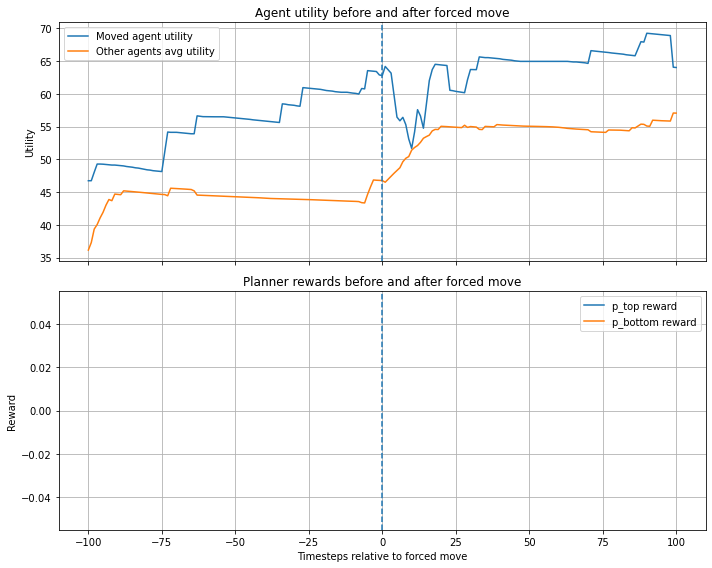

In [ ]:
fig, df_util = single.plot_forced_move_utilities_system(forced_log, window=100)
df_util.head()

In [ ]:
df_delta = single.forced_move_delta_table(forced_log, window_before=100, window_after=100)
df_delta

,group,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,0,101,101,-36.988125,14.96,8.679818,5,55.0,40,-65.0,13,16,12,-1,NaN,NaN
1,other_agents,0,101,101,43.988125,17.99,10.104520,6,-48.0,12,65.0,8,5,-7,6,NaN,NaN
